# Portfolio Optimisation: Mean-Variance, Black-Litterman and Robust Methods

**Markowitz is an error maximiser.** Feed it noisy expected returns and it concentrates the
portfolio into whatever it most overestimated. This notebook builds the classical optimiser,
demonstrates the failure quantitatively, then applies the fixes that are actually used at scale:

| Fix | What it addresses |
|---|---|
| Ledoit-Wolf covariance shrinkage | Noise and ill-conditioning in Σ̂ |
| Mean shrinkage | Noise in μ̂ (the larger problem, per Chopra & Ziemba 1993) |
| Michaud resampled frontier | Corner solutions; averages over estimation error |
| Black-Litterman | Replaces μ̂ with market-implied equilibrium + views |
| Realistic constraints | Position caps, sector caps, turnover limits |

Every method is then run through a **walk-forward backtest with transaction costs** and
benchmarked against equal weight (1/N), minimum variance and risk parity.

> **Reading guide.** Sections 1–3 write the package to disk and load data. Sections 4–7 are
> static experiments on one estimation window that show *why* things break. Sections 8–12
> are the out-of-sample horse race. Section 13 is the interpretation.

**Data:** Yahoo Finance (prices), FRED (3-month T-bill), yfinance shares outstanding (market-cap proxy).
**Universe:** 16 US large caps across 10 sectors, 2010 → present, monthly rebalancing, 2-year estimation window.

## 1. Setup

In [1]:
# Install what Colab does not ship with. cvxpy is usually present; yfinance often is not.
import importlib, subprocess, sys

def ensure(pkg, mod):
    try:
        importlib.import_module(mod); return
    except ImportError:
        pass
    for extra in ([], ["--break-system-packages"]):          # second form for PEP-668 systems
        if subprocess.call([sys.executable, "-m", "pip", "install", "-q", pkg] + extra) == 0:
            return
    print(f"WARNING: could not install {pkg}; some features may be unavailable")

for pkg, mod in [("yfinance", "yfinance"), ("cvxpy", "cvxpy"), ("scikit-learn", "sklearn"), ("tqdm", "tqdm")]:
    ensure(pkg, mod)
print("dependencies ready")

dependencies ready


In [2]:
import os, sys, warnings, logging, time
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING, format="%(levelname)s %(name)s: %(message)s")

# Optional: persist data cache and outputs to Google Drive across Colab sessions.
USE_DRIVE = False
if USE_DRIVE:
    from google.colab import drive  # type: ignore
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/portfolio-optimisation")

for d in ["src/portopt", "data/cache", "outputs/figures", "outputs/tables", "tests"]:
    os.makedirs(d, exist_ok=True)
if os.path.abspath("src") not in sys.path:
    sys.path.insert(0, os.path.abspath("src"))
print("working directory:", os.getcwd())

working directory: /tmp/nbrun


## 2. Package source

The project is written as an importable package (`src/portopt/`) rather than one long script.
The cells below write each module to disk; later cells import from it. In a cloned repository
you would skip this section and `pip install -e .` instead.

```
portfolio-optimisation/
├── README.md
├── requirements.txt
├── notebooks/portfolio_optimisation.ipynb     ← this file
├── src/portopt/
│   ├── config.py           universe, sectors, constraints, hyper-parameters
│   ├── data.py             Yahoo/FRED loaders, market-cap proxy, quality gate
│   ├── estimators.py       sample / Ledoit-Wolf / constant-corr / EWMA covariance, mean shrinkage
│   ├── optimisers.py       compiled cvxpy engine, risk parity, Michaud resampling
│   ├── black_litterman.py  equilibrium, views, posterior
│   ├── backtest.py         walk-forward engine with drift, turnover, costs
│   ├── metrics.py          performance statistics, Sharpe difference test
│   ├── analysis.py         static experiments
│   └── plots.py            figures
├── tests/test_portopt.py   17 offline unit tests
├── data/cache/             downloaded prices and rates (git-ignored)
└── outputs/{figures,tables}/
```

### `portopt/__init__.py`

Package docstring and version.

In [3]:
%%writefile src/portopt/__init__.py
"""
portopt - Portfolio optimisation: mean-variance, Black-Litterman and robust methods.

Modules
-------
config           universe, constraints, model and backtest settings
data             Yahoo Finance / FRED loaders, market-cap proxy, quality checks
estimators       mean and covariance estimators (sample, Ledoit-Wolf, EWMA)
optimisers       compiled cvxpy engine: MVO, min-var, max-Sharpe, frontier, risk parity, Michaud
black_litterman  equilibrium returns, views, posterior
backtest         walk-forward engine with drift, turnover and costs
metrics          performance statistics and Sharpe difference test
analysis         static experiments (frontiers, instability, BL walkthrough, cost sensitivity)
plots            figures
"""
__version__ = "1.0.0"

Writing src/portopt/__init__.py


### `portopt/config.py`

Everything a researcher might change: universe, sector map, constraint levels, lookback, resampling draws, Black-Litterman τ and view parameters, rebalance frequency, cost grid.

In [4]:
%%writefile src/portopt/config.py
"""
Central configuration for the portfolio optimisation project.

Everything that a researcher might want to change lives here: the asset
universe, sector map, sample window, constraint set and backtest settings.
Nothing in the other modules hard-codes these values.
"""
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Dict, List, Optional

# --------------------------------------------------------------------------- #
# Universe
# --------------------------------------------------------------------------- #
# Sixteen large-cap US equities spanning ten GICS sectors. Individual stocks
# rather than ETFs so that (a) market caps exist for Black-Litterman
# equilibrium weights and (b) sector caps are meaningful constraints.
UNIVERSE: List[str] = [
    "AAPL", "MSFT", "NVDA",          # Information Technology
    "AMZN", "HD",                    # Consumer Discretionary
    "JPM", "GS",                     # Financials
    "JNJ", "UNH",                    # Health Care
    "XOM", "CVX",                    # Energy
    "PG", "KO",                      # Consumer Staples
    "CAT",                           # Industrials
    "NEE",                           # Utilities
    "LIN",                           # Materials
]

SECTOR_MAP: Dict[str, str] = {
    "AAPL": "Technology", "MSFT": "Technology", "NVDA": "Technology",
    "AMZN": "Consumer Discretionary", "HD": "Consumer Discretionary",
    "JPM": "Financials", "GS": "Financials",
    "JNJ": "Health Care", "UNH": "Health Care",
    "XOM": "Energy", "CVX": "Energy",
    "PG": "Consumer Staples", "KO": "Consumer Staples",
    "CAT": "Industrials",
    "NEE": "Utilities",
    "LIN": "Materials",
}

# Fallback shares outstanding (billions) used ONLY if the live fetch fails.
# Approximate values; they are used to build a historical market-cap proxy
# (shares x price) so only relative magnitudes matter for equilibrium weights.
FALLBACK_SHARES_OUTSTANDING_BN: Dict[str, float] = {
    "AAPL": 14.6, "MSFT": 7.4, "NVDA": 24.4, "AMZN": 10.6, "HD": 1.0,
    "JPM": 2.8, "GS": 0.31, "JNJ": 2.4, "UNH": 0.91, "XOM": 4.3,
    "CVX": 1.75, "PG": 2.35, "KO": 4.3, "CAT": 0.47, "NEE": 2.06, "LIN": 0.47,
}

MARKET_PROXY: str = "SPY"          # used for CAPM-style diagnostics only


# --------------------------------------------------------------------------- #
# Dates and data
# --------------------------------------------------------------------------- #
@dataclass
class DataConfig:
    start: str = "2010-01-01"
    end: Optional[str] = None          # None -> today
    cache_dir: str = "data/cache"
    fred_series: str = "DGS3MO"        # 3-month T-bill, constant maturity, %
    trading_days: int = 252
    min_history_fraction: float = 0.98  # drop tickers with < 98% of the dates


# --------------------------------------------------------------------------- #
# Constraints
# --------------------------------------------------------------------------- #
@dataclass
class ConstraintConfig:
    long_only: bool = True
    max_weight: float = 0.20           # per-position cap
    max_sector_weight: float = 0.35    # per-sector cap
    max_turnover: float = 0.50         # sum |w_new - w_old| per rebalance (2 = unconstrained)


# --------------------------------------------------------------------------- #
# Estimation and model hyper-parameters
# --------------------------------------------------------------------------- #
@dataclass
class ModelConfig:
    lookback_days: int = 504           # 2 years of daily data for mu / Sigma
    n_resample: int = 100              # Michaud bootstrap draws (backtest)
    n_resample_static: int = 300       # Michaud draws for the static frontier
    bl_tau: float = 0.05               # Black-Litterman scaling of prior uncertainty
    bl_default_delta: float = 2.5      # risk aversion if market-implied estimate is unusable
    bl_delta_bounds: tuple = (1.0, 5.0)
    bl_momentum_lookback: int = 252    # 12-1 momentum window (days)
    bl_momentum_skip: int = 21         # skip most recent month
    bl_momentum_view_ann: float = 0.05 # top basket beats bottom basket by 5% p.a.
    bl_top_bottom_k: int = 4           # basket size for the relative view
    risk_parity_max_iter: int = 500


# --------------------------------------------------------------------------- #
# Backtest
# --------------------------------------------------------------------------- #
@dataclass
class BacktestConfig:
    rebalance_freq: str = "ME"        # pandas offset alias: month end
    cost_bps: float = 10.0            # cost per unit of traded notional
    cost_grid_bps: List[float] = field(default_factory=lambda: [0, 5, 10, 25, 50, 100])
    initial_weights: str = "equal"    # starting point for the turnover constraint


DATA = DataConfig()
CONSTRAINTS = ConstraintConfig()
MODEL = ModelConfig()
BACKTEST = BacktestConfig()

Writing src/portopt/config.py


### `portopt/data.py`

Downloads with retry and caching, a data-quality gate that fails loudly, the FRED risk-free series, and a **point-in-time market-cap proxy** (current shares × historical price) so equilibrium weights do not embed knowledge of which companies later grew.

In [5]:
%%writefile src/portopt/data.py
"""
Data acquisition layer.

Responsibilities
----------------
* Download adjusted prices from Yahoo Finance with local caching.
* Download the risk-free rate from FRED (no API key required).
* Build a point-in-time market-cap proxy (current shares outstanding x
  historical price) for Black-Litterman equilibrium weights.
* Run data-quality checks and fail loudly on problems that would corrupt
  downstream estimates.
* Provide a synthetic fallback so the pipeline can be unit-tested offline.

Every public function returns pandas objects indexed by a tz-naive
DatetimeIndex and aligned to the trading calendar of the price data.
"""
from __future__ import annotations

import io
import logging
import os
import time
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import requests

from .config import (DATA, FALLBACK_SHARES_OUTSTANDING_BN, SECTOR_MAP,
                     UNIVERSE, DataConfig)

logger = logging.getLogger(__name__)

FRED_CSV_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}"


# --------------------------------------------------------------------------- #
# Helpers
# --------------------------------------------------------------------------- #
def _cache_path(cfg: DataConfig, name: str) -> str:
    os.makedirs(cfg.cache_dir, exist_ok=True)
    return os.path.join(cfg.cache_dir, name)


def _retry(fn, attempts: int = 3, wait: float = 2.0, label: str = "call"):
    """Retry a callable with linear back-off. Re-raises the last exception."""
    last_exc: Optional[Exception] = None
    for i in range(1, attempts + 1):
        try:
            return fn()
        except Exception as exc:  # noqa: BLE001 - we want to retry on anything
            last_exc = exc
            logger.warning("%s failed (attempt %d/%d): %s", label, i, attempts, exc)
            time.sleep(wait * i)
    assert last_exc is not None
    raise last_exc


# --------------------------------------------------------------------------- #
# Prices
# --------------------------------------------------------------------------- #
def load_prices(tickers: Iterable[str] = UNIVERSE,
                cfg: DataConfig = DATA,
                force_refresh: bool = False) -> pd.DataFrame:
    """
    Adjusted close prices, one column per ticker.

    Prices are cached to CSV keyed on the ticker set and date range.
    Adjusted closes (auto_adjust=True) already incorporate splits and
    dividends, so simple returns on them are total returns.
    """
    tickers = sorted(set(tickers))
    end = cfg.end or pd.Timestamp.today().strftime("%Y-%m-%d")
    cache = _cache_path(cfg, f"prices_{cfg.start}_{end}_{len(tickers)}.csv")

    if os.path.exists(cache) and not force_refresh:
        prices = pd.read_csv(cache, index_col=0, parse_dates=True)
        if set(prices.columns) == set(tickers):
            logger.info("Loaded %d tickers from cache %s", len(tickers), cache)
            return prices[tickers]

    import yfinance as yf  # imported lazily so tests can run without it

    def _download() -> pd.DataFrame:
        raw = yf.download(tickers, start=cfg.start, end=end,
                          auto_adjust=True, progress=False, threads=True)
        if raw.empty:
            raise RuntimeError("Yahoo Finance returned an empty frame")
        close = raw["Close"] if isinstance(raw.columns, pd.MultiIndex) else raw[["Close"]]
        if isinstance(close, pd.Series):
            close = close.to_frame(tickers[0])
        return close

    prices = _retry(_download, label="yfinance download")
    prices.index = pd.to_datetime(prices.index).tz_localize(None)
    prices = prices.sort_index()
    prices.columns = [str(c) for c in prices.columns]
    prices = prices.reindex(columns=tickers)

    try:
        prices.to_csv(cache)
    except Exception as exc:  # read-only filesystem etc. - caching is best-effort
        logger.warning("Could not write price cache: %s", exc)
    return prices


def clean_prices(prices: pd.DataFrame,
                 cfg: DataConfig = DATA) -> Tuple[pd.DataFrame, Dict[str, str]]:
    """
    Data-quality gate.

    * Drops tickers with insufficient history.
    * Forward-fills isolated gaps (max 5 days) and reports them.
    * Drops any leading rows where not every ticker has a price.
    * Raises on non-positive prices or on duplicated dates.

    Returns the cleaned frame and a dict of issues found, for the report.
    """
    issues: Dict[str, str] = {}
    px = prices.copy()

    if px.index.duplicated().any():
        raise ValueError("Duplicated dates in price index")

    coverage = px.notna().mean()
    thin = coverage[coverage < cfg.min_history_fraction]
    for t, c in thin.items():
        issues[t] = f"dropped: only {c:.1%} of dates have a price"
    px = px.drop(columns=thin.index)

    gap_counts = px.isna().sum()
    for t, n in gap_counts[gap_counts > 0].items():
        issues[t] = issues.get(t, "") + f" filled {int(n)} missing price(s)"
    px = px.ffill(limit=5)
    px = px.dropna(how="any")          # remove leading NaNs / anything unfillable

    if (px <= 0).any().any():
        bad = px.columns[(px <= 0).any()].tolist()
        raise ValueError(f"Non-positive prices found for {bad}")

    return px, issues


def compute_returns(prices: pd.DataFrame) -> pd.DataFrame:
    """Simple daily returns. Simple (not log) because portfolio returns aggregate linearly."""
    rets = prices.pct_change().iloc[1:]
    # Guard against corporate-action glitches that produce absurd single-day moves.
    extreme = (rets.abs() > 0.5)
    if extreme.any().any():
        n = int(extreme.sum().sum())
        logger.warning("%d daily returns exceed +/-50%%; inspect before trusting results", n)
    return rets


# --------------------------------------------------------------------------- #
# Risk-free rate
# --------------------------------------------------------------------------- #
def load_risk_free(index: pd.DatetimeIndex,
                   cfg: DataConfig = DATA,
                   force_refresh: bool = False) -> pd.Series:
    """
    Daily risk-free rate aligned to `index`, derived from a FRED yield series
    quoted in percent (annualised, bond-equivalent). Falls back to zero with a
    loud warning if FRED is unreachable, so the pipeline never silently uses a
    stale number.
    """
    cache = _cache_path(cfg, f"fred_{cfg.fred_series}.csv")
    try:
        if os.path.exists(cache) and not force_refresh:
            raw = pd.read_csv(cache, index_col=0, parse_dates=True)
        else:
            resp = _retry(lambda: requests.get(FRED_CSV_URL.format(series=cfg.fred_series), timeout=30),
                          label="FRED download")
            resp.raise_for_status()
            raw = pd.read_csv(io.StringIO(resp.text), index_col=0, parse_dates=True)
            raw.to_csv(cache)
        yld = pd.to_numeric(raw.iloc[:, 0], errors="coerce")
    except Exception as exc:  # noqa: BLE001
        logger.error("Risk-free download failed (%s). Using 0%% - Sharpe ratios will be overstated.", exc)
        return pd.Series(0.0, index=index, name="rf_daily")

    yld = yld.reindex(index.union(yld.index)).ffill().reindex(index)
    yld = yld.fillna(0.0)
    daily = (1.0 + yld / 100.0) ** (1.0 / cfg.trading_days) - 1.0
    daily.name = "rf_daily"
    return daily


# --------------------------------------------------------------------------- #
# Market capitalisation proxy
# --------------------------------------------------------------------------- #
def load_shares_outstanding(tickers: Iterable[str]) -> pd.Series:
    """
    Current shares outstanding per ticker via yfinance fast_info, with a
    hard-coded fallback. Wrapped per-ticker so one failure does not sink all.
    """
    tickers = list(tickers)
    out: Dict[str, float] = {}
    try:
        import yfinance as yf
        for t in tickers:
            try:
                fi = yf.Ticker(t).fast_info
                shares = fi.get("shares") or fi.get("sharesOutstanding")
                if shares and shares > 0:
                    out[t] = float(shares)
                    continue
            except Exception as exc:  # noqa: BLE001
                logger.warning("shares lookup failed for %s: %s", t, exc)
            out[t] = FALLBACK_SHARES_OUTSTANDING_BN.get(t, np.nan) * 1e9
    except ImportError:
        out = {t: FALLBACK_SHARES_OUTSTANDING_BN.get(t, np.nan) * 1e9 for t in tickers}

    s = pd.Series(out, name="shares_outstanding")
    if s.isna().any():
        missing = s.index[s.isna()].tolist()
        raise ValueError(f"No shares outstanding available for {missing}")
    return s


def market_cap_proxy(prices: pd.DataFrame, shares: pd.Series) -> pd.DataFrame:
    """
    Historical market-cap proxy = current shares outstanding x historical price.

    This ignores buybacks and issuance over time, but it is point-in-time
    with respect to *prices*, which is what matters for avoiding lookahead in
    the equilibrium weights. Using today's market caps for 2012 rebalances
    would embed knowledge of which companies later grew.
    """
    shares = shares.reindex(prices.columns)
    return prices.mul(shares, axis=1)


def market_weights_at(caps: pd.DataFrame, date: pd.Timestamp) -> pd.Series:
    """Cap-weighted vector on a date (last available on or before `date`)."""
    row = caps.loc[:date].iloc[-1]
    return row / row.sum()


# --------------------------------------------------------------------------- #
# Sectors
# --------------------------------------------------------------------------- #
def sector_matrix(tickers: List[str],
                  sector_map: Dict[str, str] = SECTOR_MAP) -> pd.DataFrame:
    """
    Binary (sectors x assets) matrix A such that A @ w = sector weights.
    Tickers missing from the map are assigned to 'Other' with a warning.
    """
    rows = {}
    for t in tickers:
        sec = sector_map.get(t)
        if sec is None:
            logger.warning("No sector for %s; assigning 'Other'", t)
            sec = "Other"
        rows[t] = sec
    sectors = sorted(set(rows.values()))
    mat = pd.DataFrame(0.0, index=sectors, columns=tickers)
    for t, sec in rows.items():
        mat.loc[sec, t] = 1.0
    return mat


# --------------------------------------------------------------------------- #
# Synthetic fallback (offline tests / demos)
# --------------------------------------------------------------------------- #
def synthetic_prices(tickers: List[str] = UNIVERSE,
                     n_days: int = 2520,
                     seed: int = 7,
                     start: str = "2015-01-01") -> pd.DataFrame:
    """
    Geometric Brownian motion with a one-factor correlation structure.
    Deterministic given `seed`. Used only when live data is unavailable.
    """
    rng = np.random.default_rng(seed)
    n = len(tickers)
    beta = rng.uniform(0.6, 1.4, n)
    idio = rng.uniform(0.15, 0.35, n) / np.sqrt(252)
    mkt = rng.normal(0.0004, 0.011, n_days)
    eps = rng.normal(0, 1, (n_days, n)) * idio
    rets = np.outer(mkt, beta) + eps + rng.uniform(0.0, 0.0003, n)
    idx = pd.bdate_range(start, periods=n_days)
    return pd.DataFrame(100 * np.cumprod(1 + rets, axis=0), index=idx, columns=tickers)


def load_all(cfg: DataConfig = DATA,
             tickers: Iterable[str] = UNIVERSE,
             use_synthetic: bool = False) -> Dict[str, object]:
    """
    One-call loader used by the notebook. Returns a dict with:
    prices, returns, rf, caps, sectors (matrix), shares, issues.
    """
    tickers = list(tickers)
    if use_synthetic:
        logger.warning("Using SYNTHETIC prices - results are illustrative only")
        prices = synthetic_prices(tickers)
        shares = pd.Series({t: FALLBACK_SHARES_OUTSTANDING_BN.get(t, 1.0) * 1e9 for t in tickers})
        issues: Dict[str, str] = {"_mode": "synthetic"}
    else:
        prices = load_prices(tickers, cfg)
        prices, issues = clean_prices(prices, cfg)
        shares = load_shares_outstanding(prices.columns)

    returns = compute_returns(prices)
    rf = load_risk_free(returns.index, cfg) if not use_synthetic else pd.Series(0.02 / 252, index=returns.index)
    caps = market_cap_proxy(prices, shares)
    sectors = sector_matrix(list(prices.columns))
    return dict(prices=prices, returns=returns, rf=rf, caps=caps,
                sectors=sectors, shares=shares, issues=issues)

Writing src/portopt/data.py


### `portopt/estimators.py`

Annualised mean and covariance estimators. Ledoit-Wolf via scikit-learn plus a faithful port of the constant-correlation variant; James-Stein style mean shrinkage.

In [6]:
%%writefile src/portopt/estimators.py
"""
Return and covariance estimators.

All estimators take a (T x N) DataFrame of *daily* simple returns and return
annualised quantities, so that everything downstream works in annual units
and Sharpe ratios are directly interpretable.

Available covariance estimators
-------------------------------
sample       : plain sample covariance (the thing that breaks Markowitz)
ledoit_wolf  : Ledoit-Wolf (2004) shrinkage toward a scaled identity target
const_corr   : Ledoit-Wolf (2003) shrinkage toward constant correlation
ewma         : exponentially weighted covariance (RiskMetrics style)
"""
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional

import numpy as np
import pandas as pd
from sklearn.covariance import LedoitWolf

TRADING_DAYS = 252


@dataclass
class Estimates:
    """Container for one set of inputs to an optimiser (annualised)."""
    mu: pd.Series
    cov: pd.DataFrame
    label: str = ""

    @property
    def assets(self) -> list:
        return list(self.mu.index)

    def as_arrays(self):
        return self.mu.values.astype(float), self.cov.values.astype(float)


# --------------------------------------------------------------------------- #
# Expected returns
# --------------------------------------------------------------------------- #
def mean_historical(returns: pd.DataFrame, periods: int = TRADING_DAYS) -> pd.Series:
    """Arithmetic mean daily return, annualised. Extremely noisy; that is the point."""
    return returns.mean() * periods


def mean_shrunk(returns: pd.DataFrame, shrink: float = 0.5,
                periods: int = TRADING_DAYS) -> pd.Series:
    """
    James-Stein style shrinkage of the mean vector toward the cross-sectional
    grand mean. `shrink=1` collapses all expected returns to a single value,
    which makes mean-variance identical to minimum variance.
    """
    mu = mean_historical(returns, periods)
    grand = mu.mean()
    return (1 - shrink) * mu + shrink * grand


# --------------------------------------------------------------------------- #
# Covariance
# --------------------------------------------------------------------------- #
def cov_sample(returns: pd.DataFrame, periods: int = TRADING_DAYS) -> pd.DataFrame:
    return returns.cov() * periods


def cov_ledoit_wolf(returns: pd.DataFrame, periods: int = TRADING_DAYS) -> pd.DataFrame:
    """
    Ledoit-Wolf shrinkage toward mu*I where mu is the average variance.
    Optimal shrinkage intensity is estimated analytically from the data.
    """
    lw = LedoitWolf(assume_centered=False).fit(returns.values)
    cov = pd.DataFrame(lw.covariance_ * periods, index=returns.columns, columns=returns.columns)
    cov.attrs["shrinkage"] = float(lw.shrinkage_)
    return cov


def cov_constant_correlation(returns: pd.DataFrame,
                             periods: int = TRADING_DAYS) -> pd.DataFrame:
    """
    Ledoit & Wolf (2003) "Honey, I shrunk the sample covariance matrix".
    Target: all pairwise correlations equal to their average. The shrinkage
    intensity formula follows the paper's Appendix B.
    """
    # Port of Ledoit & Wolf's reference implementation (covCor.m).
    x = returns.values - returns.values.mean(axis=0)
    t, n = x.shape
    sample = (x.T @ x) / t
    var = np.diag(sample)
    sd = np.sqrt(var)
    r_bar = (np.sum(sample / np.outer(sd, sd)) - n) / (n * (n - 1))
    target = r_bar * np.outer(sd, sd)
    np.fill_diagonal(target, var)

    # pi-hat: asymptotic variance of the sample covariance entries
    y = x ** 2
    phi_mat = (y.T @ y) / t - 2 * (x.T @ x) * sample / t + sample ** 2
    phi = phi_mat.sum()

    # rho-hat: asymptotic covariance between sample and target errors
    term1 = ((x ** 3).T @ x) / t
    help_ = (x.T @ x) / t
    help_diag = np.diag(help_)[:, None]
    term2 = help_diag * sample
    term3 = help_ * var[:, None]
    term4 = var[:, None] * sample
    theta = term1 - term2 - term3 + term4
    np.fill_diagonal(theta, 0.0)
    rho = np.diag(phi_mat).sum() + r_bar * (np.outer(1.0 / sd, sd) * theta).sum()

    gamma = np.linalg.norm(sample - target, "fro") ** 2
    kappa = (phi - rho) / gamma if gamma > 0 else 0.0
    shrink = float(np.clip(kappa / t, 0.0, 1.0))
    cov = shrink * target + (1 - shrink) * sample
    out = pd.DataFrame(cov * periods, index=returns.columns, columns=returns.columns)
    out.attrs["shrinkage"] = shrink
    return out


def cov_ewma(returns: pd.DataFrame, halflife: int = 63,
             periods: int = TRADING_DAYS) -> pd.DataFrame:
    """Exponentially weighted covariance with the given half-life in days."""
    cov = returns.ewm(halflife=halflife, min_periods=halflife).cov().iloc[-len(returns.columns):]
    cov.index = cov.index.get_level_values(1)
    return cov * periods


def nearest_psd(cov: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    """Clip negative eigenvalues; used defensively before Cholesky."""
    sym = (cov + cov.T) / 2
    vals, vecs = np.linalg.eigh(sym)
    vals = np.clip(vals, eps, None)
    return (vecs * vals) @ vecs.T


def cholesky_factor(cov: np.ndarray) -> np.ndarray:
    """Lower-triangular L with cov = L L'. Adds jitter if needed."""
    cov = np.asarray(cov, dtype=float)
    try:
        return np.linalg.cholesky(cov)
    except np.linalg.LinAlgError:
        return np.linalg.cholesky(nearest_psd(cov) + 1e-10 * np.eye(len(cov)))


# --------------------------------------------------------------------------- #
# Convenience
# --------------------------------------------------------------------------- #
def estimate(returns: pd.DataFrame, cov_method: str = "ledoit_wolf",
             mean_method: str = "historical", label: Optional[str] = None) -> Estimates:
    """Build an `Estimates` object from a returns window."""
    cov_fn = {
        "sample": cov_sample,
        "ledoit_wolf": cov_ledoit_wolf,
        "const_corr": cov_constant_correlation,
        "ewma": cov_ewma,
    }[cov_method]
    mean_fn = {"historical": mean_historical, "shrunk": mean_shrunk}[mean_method]
    return Estimates(mu=mean_fn(returns), cov=cov_fn(returns),
                     label=label or f"{mean_method}/{cov_method}")


def condition_number(cov: pd.DataFrame) -> float:
    vals = np.linalg.eigvalsh(cov.values)
    return float(vals.max() / max(vals.min(), 1e-16))

Writing src/portopt/estimators.py


### `portopt/optimisers.py`

All convex problems are compiled **once** with cvxpy's DPP and re-solved by updating parameters (2 ms per solve). The covariance enters through its Cholesky factor so the problems stay DPP-compliant. Max-Sharpe uses the Charnes-Cooper transform; risk parity uses Spinu's convex log-barrier formulation with a SLSQP fallback when caps bind; Michaud resampling averages optimal weights across simulated histories.

In [7]:
%%writefile src/portopt/optimisers.py
"""
Portfolio optimisers.

Design
------
All convex problems are compiled once per (universe, constraint set) via
cvxpy's Disciplined Parametrized Programming (DPP). Subsequent solves only
update parameter values, which makes the walk-forward backtest and the
Michaud resampling loop (thousands of solves) fast.

The covariance enters through its Cholesky factor L (Sigma = L L') so that
the risk term `sum_squares(L.T @ w)` is DPP-compliant; `quad_form(w, Sigma)`
with a parametrised Sigma is not.

Objectives
----------
mean_variance : max  mu'w - (lambda/2) w'Sigma w
min_variance  : min  w'Sigma w
max_sharpe    : max  (mu'w - rf) / sqrt(w'Sigma w)   (Charnes-Cooper transform)
target_return : min  w'Sigma w  s.t. mu'w >= r       (efficient frontier)
risk_parity   : equal (or budgeted) risk contributions
resampled     : Michaud (1998) averaging of optimal weights across bootstraps

Constraint set (all optional)
-----------------------------
fully invested, long-only, per-asset cap, per-sector cap, L1 turnover cap
relative to the previous weights.
"""
from __future__ import annotations

import logging
from dataclasses import dataclass, field
from typing import Callable, Dict, List, Optional

import cvxpy as cp
import numpy as np
import pandas as pd
from scipy.optimize import minimize

from .config import CONSTRAINTS, ConstraintConfig
from .estimators import Estimates, cholesky_factor

logger = logging.getLogger(__name__)

SOLVER_ORDER = [cp.CLARABEL, cp.OSQP, cp.SCS]


# --------------------------------------------------------------------------- #
# Constraint specification
# --------------------------------------------------------------------------- #
@dataclass
class ConstraintSet:
    """
    Numeric constraint set for a fixed universe of size n.

    sector_matrix : (k x n) binary matrix, row k sums the weights in sector k.
    """
    n: int
    long_only: bool = True
    max_weight: Optional[float] = 0.20
    sector_matrix: Optional[np.ndarray] = None
    max_sector_weight: Optional[float] = 0.35
    max_turnover: Optional[float] = 0.50

    @classmethod
    def from_config(cls, n: int, sector_matrix: Optional[np.ndarray] = None,
                    cfg: ConstraintConfig = CONSTRAINTS) -> "ConstraintSet":
        return cls(n=n, long_only=cfg.long_only, max_weight=cfg.max_weight,
                   sector_matrix=sector_matrix, max_sector_weight=cfg.max_sector_weight,
                   max_turnover=cfg.max_turnover)

    def unconstrained(self) -> "ConstraintSet":
        """Long-only, fully invested, nothing else. Useful for illustrations."""
        return ConstraintSet(n=self.n, long_only=True, max_weight=None,
                             sector_matrix=None, max_sector_weight=None, max_turnover=None)

    def validate(self) -> None:
        if self.max_weight is not None and self.max_weight * self.n < 1.0 - 1e-9:
            raise ValueError(f"max_weight={self.max_weight} infeasible for n={self.n}")
        if self.sector_matrix is not None and self.max_sector_weight is not None:
            k = self.sector_matrix.shape[0]
            if self.max_sector_weight * k < 1.0 - 1e-9:
                raise ValueError("Sector caps cannot sum to less than 100%")


def _cvx_constraints(w, cs: ConstraintSet, w_prev, tau, scale=None) -> list:
    """
    Build cvxpy constraints for weight vector `w`.
    `scale` is the homogenising variable kappa in the max-Sharpe transform;
    when None the portfolio is fully invested (sum to 1).
    """
    one = 1.0 if scale is None else scale
    cons = [cp.sum(w) == one]
    if cs.long_only:
        cons.append(w >= 0)
    if cs.max_weight is not None:
        cons.append(w <= cs.max_weight * one)
    if cs.sector_matrix is not None and cs.max_sector_weight is not None:
        cons.append(cs.sector_matrix @ w <= cs.max_sector_weight * one)
    if cs.max_turnover is not None and w_prev is not None:
        cons.append(cp.norm1(w - one * w_prev) <= tau * one)
    return cons


# --------------------------------------------------------------------------- #
# Compiled convex engine
# --------------------------------------------------------------------------- #
class ConvexEngine:
    """
    Holds compiled cvxpy problems for one universe and constraint set.

    Parameters updated per solve: Cholesky factor L, expected returns mu,
    previous weights w_prev, turnover cap tau, target return r_target.
    """

    def __init__(self, cs: ConstraintSet):
        cs.validate()
        self.cs = cs
        n = cs.n
        self.n = n

        # Shared parameters
        self.L = cp.Parameter((n, n), name="L")
        self.mu = cp.Parameter(n, name="mu")
        self.w_prev = cp.Parameter(n, name="w_prev", value=np.full(n, 1.0 / n))
        self.tau = cp.Parameter(nonneg=True, name="tau", value=2.0)
        self.r_target = cp.Parameter(name="r_target", value=0.0)
        self.mu_excess = cp.Parameter(n, name="mu_excess")

        # ---- Problem A: mean-variance utility  (mu pre-scaled by 1/lambda) --
        self.w = cp.Variable(n, name="w")
        risk = cp.sum_squares(self.L.T @ self.w)
        self._mv = cp.Problem(cp.Minimize(0.5 * risk - self.mu @ self.w),
                              _cvx_constraints(self.w, cs, self.w_prev, self.tau))

        # ---- Problem B: target-return (frontier) ----------------------------
        self._tr = cp.Problem(cp.Minimize(risk),
                              _cvx_constraints(self.w, cs, self.w_prev, self.tau)
                              + [self.mu @ self.w >= self.r_target])

        # ---- Problem C: max Sharpe via Charnes-Cooper -----------------------
        self.y = cp.Variable(n, name="y")
        self.kappa = cp.Variable(nonneg=True, name="kappa")
        self._ms = cp.Problem(cp.Minimize(cp.sum_squares(self.L.T @ self.y)),
                              _cvx_constraints(self.y, cs, self.w_prev, self.tau, scale=self.kappa)
                              + [self.mu_excess @ self.y == 1])

        # ---- Problem D: max expected return (LP, frontier upper bound) ------
        self._mr = cp.Problem(cp.Maximize(self.mu @ self.w),
                              _cvx_constraints(self.w, cs, self.w_prev, self.tau))

        # ---- Problem E: risk parity via Spinu's convex formulation ----------
        # min 0.5 y'Sigma y - sum b_i log(y_i);  w = y / sum(y). Exact ERC for
        # long-only; caps are checked afterwards and a SLSQP fallback is used.
        self.b = cp.Parameter(n, nonneg=True, name="budgets", value=np.full(n, 1.0 / n))
        self.y_rp = cp.Variable(n, name="y_rp")
        self._rp = cp.Problem(cp.Minimize(0.5 * cp.sum_squares(self.L.T @ self.y_rp)
                                          - self.b @ cp.log(self.y_rp)))

        for p in (self._mv, self._tr, self._ms, self._mr, self._rp):
            if not p.is_dcp(dpp=True):
                logger.warning("Problem is not DPP-compliant; solves will be slower")

    # -- utilities -----------------------------------------------------------
    def _set_inputs(self, mu, cov, w_prev=None, tau=None):
        self.L.value = cholesky_factor(cov)
        self.mu.value = np.asarray(mu, dtype=float)
        if w_prev is not None:
            self.w_prev.value = np.asarray(w_prev, dtype=float)
            self.tau.value = float(tau if tau is not None else (self.cs.max_turnover or 2.0))
        else:
            self.w_prev.value = np.full(self.n, 1.0 / self.n)
            self.tau.value = 2.0   # L1 distance can never exceed 2 -> inactive

    @staticmethod
    def _solve(problem: cp.Problem) -> bool:
        for solver in SOLVER_ORDER:
            try:
                problem.solve(solver=solver, warm_start=True)
                if problem.status in (cp.OPTIMAL, cp.OPTIMAL_INACCURATE):
                    return True
            except (cp.SolverError, ValueError) as exc:
                logger.debug("solver %s failed: %s", solver, exc)
        return False

    @staticmethod
    def _clean(w: np.ndarray) -> np.ndarray:
        w = np.asarray(w, dtype=float).copy()
        w[np.abs(w) < 1e-8] = 0.0
        w = np.clip(w, 0.0, None) if (w >= -1e-6).all() else w
        return w / w.sum()

    # -- public solves -------------------------------------------------------
    def mean_variance(self, mu, cov, risk_aversion: float = 2.5,
                      w_prev=None, tau=None) -> np.ndarray:
        """max mu'w - (lambda/2) w'Sigma w subject to the constraint set."""
        if risk_aversion <= 0:
            raise ValueError("risk_aversion must be positive")
        self._set_inputs(np.asarray(mu) / risk_aversion, cov, w_prev, tau)
        if not self._solve(self._mv):
            raise RuntimeError("mean_variance: no solver returned an optimal solution")
        return self._clean(self.w.value)

    def min_variance(self, cov, w_prev=None, tau=None) -> np.ndarray:
        return self.mean_variance(np.zeros(self.n), cov, 1.0, w_prev, tau)

    def max_return(self, mu, cov, w_prev=None, tau=None) -> float:
        self._set_inputs(mu, cov, w_prev, tau)
        if not self._solve(self._mr):
            raise RuntimeError("max_return LP failed")
        return float(self._mr.value)

    def max_sharpe(self, mu, cov, rf: float = 0.0, w_prev=None, tau=None,
                   fallback_min_var: bool = True) -> np.ndarray:
        """
        Tangency portfolio. If no feasible portfolio has expected excess
        return > 0 the transform is infeasible; we then fall back to the
        minimum-variance portfolio (documented behaviour, logged).
        """
        self._set_inputs(mu, cov, w_prev, tau)
        self.mu_excess.value = np.asarray(mu, dtype=float) - rf
        ok = self._solve(self._ms)
        if ok and self.kappa.value is not None and self.kappa.value > 1e-10:
            return self._clean(self.y.value / self.kappa.value)
        if fallback_min_var:
            logger.info("max_sharpe infeasible (all excess returns <= 0?); using min variance")
            return self.min_variance(cov, w_prev, tau)
        raise RuntimeError("max_sharpe infeasible")

    def target_return(self, mu, cov, r: float, w_prev=None, tau=None) -> Optional[np.ndarray]:
        self._set_inputs(mu, cov, w_prev, tau)
        self.r_target.value = float(r)
        if not self._solve(self._tr):
            return None
        return self._clean(self.w.value)

    def efficient_frontier(self, mu, cov, n_points: int = 30,
                           w_prev=None, tau=None) -> pd.DataFrame:
        """
        Sweep target returns from the min-variance return to the maximum
        feasible return. Returns a frame with columns ret, vol, and weights.
        """
        mu = np.asarray(mu, dtype=float)
        cov = np.asarray(cov, dtype=float)
        w_mv = self.min_variance(cov, w_prev, tau)
        r_lo = float(mu @ w_mv)
        r_hi = self.max_return(mu, cov, w_prev, tau)
        rows = []
        for r in np.linspace(r_lo, r_hi - 1e-9, n_points):
            w = self.target_return(mu, cov, r, w_prev, tau)
            if w is None:
                continue
            rows.append(dict(ret=float(mu @ w), vol=float(np.sqrt(w @ cov @ w)), weights=w))
        return pd.DataFrame(rows)

    def risk_parity(self, cov, budgets=None, w_prev=None, tau=None) -> np.ndarray:
        """
        Equal (or budgeted) risk contribution portfolio.

        Uses the convex log-barrier formulation, which is exact for the
        long-only case. If the result violates position or sector caps the
        problem is re-solved with SLSQP under bounds; contributions are then
        equalised as far as the caps allow.
        """
        cov = np.asarray(cov, dtype=float)
        b = np.full(self.n, 1.0 / self.n) if budgets is None else np.asarray(budgets, float)
        b = b / b.sum()
        self.L.value = cholesky_factor(cov)
        self.b.value = b
        if self._solve(self._rp) and self.y_rp.value is not None:
            w = self._clean(self.y_rp.value)
        else:
            w = 1.0 / np.sqrt(np.diag(cov)); w /= w.sum()

        if self._violates(w, w_prev):
            w = self._risk_parity_slsqp(cov, b, w0=w, w_prev=w_prev, tau=tau)
        return w

    def _violates(self, w, w_prev=None) -> bool:
        cs = self.cs
        if cs.max_weight is not None and (w > cs.max_weight + 1e-6).any():
            return True
        if cs.sector_matrix is not None and cs.max_sector_weight is not None:
            if (cs.sector_matrix @ w > cs.max_sector_weight + 1e-6).any():
                return True
        if cs.max_turnover is not None and w_prev is not None:
            if np.abs(w - w_prev).sum() > cs.max_turnover + 1e-6:
                return True
        return False

    def _risk_parity_slsqp(self, cov, b, w0, w_prev=None, tau=None) -> np.ndarray:
        cs = self.cs
        n = self.n

        def objective(w):
            port_var = w @ cov @ w
            rc = w * (cov @ w) / port_var
            return float(np.sum((rc - b) ** 2)) * 1e4

        cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
        if cs.sector_matrix is not None and cs.max_sector_weight is not None:
            cons.append({"type": "ineq",
                         "fun": lambda w: cs.max_sector_weight - cs.sector_matrix @ w})
        if cs.max_turnover is not None and w_prev is not None:
            t = tau if tau is not None else cs.max_turnover
            cons.append({"type": "ineq", "fun": lambda w: t - np.abs(w - w_prev).sum()})
        ub = cs.max_weight if cs.max_weight is not None else 1.0
        lb = 0.0 if cs.long_only else -1.0
        res = minimize(objective, np.clip(w0, lb, ub), method="SLSQP",
                       bounds=[(lb, ub)] * n, constraints=cons,
                       options={"maxiter": 500, "ftol": 1e-12})
        if not res.success:
            logger.warning("risk parity SLSQP did not converge: %s", res.message)
        return self._clean(res.x)


# --------------------------------------------------------------------------- #
# Michaud resampled optimisation
# --------------------------------------------------------------------------- #
def resampled_weights(engine: ConvexEngine, est: Estimates, n_obs: int,
                      objective: str = "max_sharpe", n_sims: int = 100,
                      rf: float = 0.0, risk_aversion: float = 2.5,
                      w_prev=None, tau=None, seed: int = 0,
                      periods: int = 252) -> np.ndarray:
    """
    Michaud (1998) resampled portfolio for a single objective.

    Treat (mu_hat, Sigma_hat) as the truth, simulate `n_sims` histories of
    `n_obs` daily returns, re-estimate on each, optimise, and average the
    weights. Averaging is the regularisation: it smooths the corner
    solutions that individual noisy estimates produce.
    """
    rng = np.random.default_rng(seed)
    mu, cov = est.as_arrays()
    mu_d, cov_d = mu / periods, cov / periods
    L = cholesky_factor(cov_d)
    acc = np.zeros(engine.n)
    used = 0
    for _ in range(n_sims):
        z = rng.standard_normal((n_obs, engine.n))
        sim = z @ L.T + mu_d
        mu_s = sim.mean(axis=0) * periods
        cov_s = np.cov(sim, rowvar=False) * periods
        try:
            if objective == "max_sharpe":
                w = engine.max_sharpe(mu_s, cov_s, rf, w_prev, tau)
            elif objective == "min_variance":
                w = engine.min_variance(cov_s, w_prev, tau)
            elif objective == "mean_variance":
                w = engine.mean_variance(mu_s, cov_s, risk_aversion, w_prev, tau)
            else:
                raise ValueError(objective)
        except RuntimeError as exc:
            logger.debug("resample draw skipped: %s", exc)
            continue
        acc += w
        used += 1
    if used == 0:
        raise RuntimeError("All resampling draws failed")
    return acc / used


def resampled_frontier(engine: ConvexEngine, est: Estimates, n_obs: int,
                       n_points: int = 25, n_sims: int = 200, seed: int = 0,
                       periods: int = 252) -> pd.DataFrame:
    """
    Michaud resampled efficient frontier: average weights *by rank* across
    simulated frontiers, then evaluate the averaged weights on the original
    estimates. Always lies inside the classical frontier (it is not
    mean-variance efficient by construction; it is more stable).
    """
    rng = np.random.default_rng(seed)
    mu, cov = est.as_arrays()
    mu_d, cov_d = mu / periods, cov / periods
    L = cholesky_factor(cov_d)
    weight_sum = np.zeros((n_points, engine.n))
    counts = np.zeros(n_points)
    for _ in range(n_sims):
        sim = rng.standard_normal((n_obs, engine.n)) @ L.T + mu_d
        mu_s, cov_s = sim.mean(axis=0) * periods, np.cov(sim, rowvar=False) * periods
        try:
            fr = engine.efficient_frontier(mu_s, cov_s, n_points)
        except RuntimeError:
            continue
        if len(fr) < n_points:
            # interpolate weights onto a fixed rank grid
            idx = np.linspace(0, len(fr) - 1, n_points).round().astype(int)
            fr = fr.iloc[idx].reset_index(drop=True)
        W = np.vstack(fr["weights"].values)
        weight_sum += W
        counts += 1
    W_bar = weight_sum / np.maximum(counts, 1)[:, None]
    rows = [dict(ret=float(mu @ w), vol=float(np.sqrt(w @ cov @ w)), weights=w) for w in W_bar]
    return pd.DataFrame(rows)


# --------------------------------------------------------------------------- #
# Simple allocations and diagnostics
# --------------------------------------------------------------------------- #
def equal_weight(n: int) -> np.ndarray:
    return np.full(n, 1.0 / n)


def inverse_volatility(cov) -> np.ndarray:
    iv = 1.0 / np.sqrt(np.diag(np.asarray(cov)))
    return iv / iv.sum()


def risk_contributions(w, cov) -> np.ndarray:
    """Fraction of portfolio variance attributable to each asset (sums to 1)."""
    w = np.asarray(w); cov = np.asarray(cov)
    port_var = w @ cov @ w
    return w * (cov @ w) / port_var


def portfolio_stats(w, mu, cov, rf: float = 0.0) -> Dict[str, float]:
    w = np.asarray(w); mu = np.asarray(mu); cov = np.asarray(cov)
    ret = float(mu @ w)
    vol = float(np.sqrt(w @ cov @ w))
    return dict(ret=ret, vol=vol, sharpe=(ret - rf) / vol if vol > 0 else np.nan,
                hhi=float(np.sum(w ** 2)), effective_n=float(1.0 / np.sum(w ** 2)),
                max_weight=float(w.max()))

Writing src/portopt/optimisers.py


### `portopt/black_litterman.py`

Reverse optimisation for Π, He-Litterman Ω, the posterior mean and covariance, and a **systematic 12-1 momentum view** so the backtest involves no discretionary (lookahead-prone) views.

In [8]:
%%writefile src/portopt/black_litterman.py
"""
Black-Litterman model (Black & Litterman 1992; He & Litterman 1999).

Pipeline
--------
1. Reverse optimisation: implied equilibrium excess returns
       Pi = delta * Sigma * w_mkt
   where delta is the market's risk aversion, estimated as
       delta = (E[r_mkt] - rf) / Var(r_mkt)   (clipped to a sane range).

2. Views: k linear views  P mu = Q + eps,  eps ~ N(0, Omega).
   Omega defaults to He-Litterman: diag(P (tau Sigma) P').

3. Posterior (the "master formula"):
       mu_BL    = [ (tau Sigma)^-1 + P' Omega^-1 P ]^-1 [ (tau Sigma)^-1 Pi + P' Omega^-1 Q ]
       Sigma_BL = Sigma + [ (tau Sigma)^-1 + P' Omega^-1 P ]^-1

   With no views the posterior collapses to the prior, and the equilibrium
   portfolio is recovered exactly by unconstrained mean-variance at delta.

The backtest uses a *systematic* view (12-1 momentum spread) so that no
human judgement, and therefore no lookahead, enters the historical test.
"""
from __future__ import annotations

from dataclasses import dataclass
from typing import List, Optional, Tuple

import numpy as np
import pandas as pd

from .config import MODEL, ModelConfig


@dataclass
class BLResult:
    prior: pd.Series            # equilibrium excess returns Pi
    posterior_mu: pd.Series     # mu_BL (excess)
    posterior_cov: pd.DataFrame
    delta: float
    P: np.ndarray
    Q: np.ndarray
    omega: np.ndarray
    view_labels: List[str]

    def summary(self) -> pd.DataFrame:
        return pd.DataFrame({"prior": self.prior, "posterior": self.posterior_mu,
                             "shift": self.posterior_mu - self.prior})


# --------------------------------------------------------------------------- #
# Equilibrium
# --------------------------------------------------------------------------- #
def implied_risk_aversion(market_returns: pd.Series, rf_daily: pd.Series,
                          cfg: ModelConfig = MODEL, periods: int = 252) -> float:
    """
    delta = (mean excess return) / variance, both annualised. Clipped to
    cfg.bl_delta_bounds because short windows can give absurd values
    (negative after a crash, huge after a calm rally).
    """
    excess = market_returns - rf_daily.reindex(market_returns.index).fillna(0.0)
    mean_ann = excess.mean() * periods
    var_ann = market_returns.var() * periods
    if var_ann <= 0 or not np.isfinite(mean_ann):
        return cfg.bl_default_delta
    delta = mean_ann / var_ann
    lo, hi = cfg.bl_delta_bounds
    return float(np.clip(delta, lo, hi))


def equilibrium_returns(cov: pd.DataFrame, w_mkt: pd.Series, delta: float) -> pd.Series:
    """Pi = delta * Sigma * w_mkt (annualised excess returns)."""
    w = w_mkt.reindex(cov.index).fillna(0.0)
    w = w / w.sum()
    return pd.Series(delta * cov.values @ w.values, index=cov.index, name="Pi")


# --------------------------------------------------------------------------- #
# Views
# --------------------------------------------------------------------------- #
def absolute_view(assets: List[str], asset: str, ret: float) -> Tuple[np.ndarray, float, str]:
    p = np.zeros(len(assets)); p[assets.index(asset)] = 1.0
    return p, ret, f"{asset} returns {ret:.1%}"


def relative_view(assets: List[str], long: List[str], short: List[str],
                  spread: float) -> Tuple[np.ndarray, float, str]:
    """Equal-weighted `long` basket outperforms `short` basket by `spread`."""
    p = np.zeros(len(assets))
    for a in long:
        p[assets.index(a)] = 1.0 / len(long)
    for a in short:
        p[assets.index(a)] = -1.0 / len(short)
    return p, spread, f"{'+'.join(long)} beats {'+'.join(short)} by {spread:.1%}"


def momentum_view(returns_window: pd.DataFrame, cfg: ModelConfig = MODEL
                  ) -> Optional[Tuple[np.ndarray, float, str]]:
    """
    Systematic relative view from 12-1 month momentum: the top-k names by
    trailing return (skipping the most recent month) are expected to beat
    the bottom-k by cfg.bl_momentum_view_ann per year.
    """
    lb, skip, k = cfg.bl_momentum_lookback, cfg.bl_momentum_skip, cfg.bl_top_bottom_k
    if len(returns_window) < lb + skip:
        return None
    window = returns_window.iloc[-(lb + skip):-skip] if skip > 0 else returns_window.iloc[-lb:]
    mom = (1 + window).prod() - 1
    ranked = mom.sort_values()
    assets = list(returns_window.columns)
    return relative_view(assets, long=list(ranked.index[-k:]),
                         short=list(ranked.index[:k]), spread=cfg.bl_momentum_view_ann)


# --------------------------------------------------------------------------- #
# Posterior
# --------------------------------------------------------------------------- #
def black_litterman(cov: pd.DataFrame, w_mkt: pd.Series, delta: float,
                    views: Optional[List[Tuple[np.ndarray, float, str]]] = None,
                    tau: float = MODEL.bl_tau,
                    omega: Optional[np.ndarray] = None,
                    view_confidence: Optional[np.ndarray] = None) -> BLResult:
    """
    Compute the Black-Litterman posterior.

    views           : list of (P_row, Q, label). None or [] -> prior only.
    omega           : explicit (k x k) view covariance, overrides default.
    view_confidence : optional per-view multipliers in (0, inf). Values < 1
                      tighten Omega (more confident), > 1 loosen it. This is
                      a simple, transparent alternative to Idzorek's method.
    """
    assets = list(cov.index)
    n = len(assets)
    pi = equilibrium_returns(cov, w_mkt, delta)
    S = cov.values
    tS = tau * S

    if not views:
        return BLResult(prior=pi, posterior_mu=pi.copy(), posterior_cov=cov.copy(),
                        delta=delta, P=np.zeros((0, n)), Q=np.zeros(0),
                        omega=np.zeros((0, 0)), view_labels=[])

    P = np.vstack([v[0] for v in views])
    Q = np.array([v[1] for v in views], dtype=float)
    labels = [v[2] for v in views]
    k = P.shape[0]
    if P.shape[1] != n:
        raise ValueError("View matrix width does not match number of assets")

    if omega is None:
        omega = np.diag(np.diag(P @ tS @ P.T))
        if view_confidence is not None:
            omega = omega * np.asarray(view_confidence, dtype=float)[:, None] * np.eye(k)
    if np.any(np.diag(omega) <= 0):
        raise ValueError("Omega must have strictly positive diagonal")

    tS_inv = np.linalg.inv(tS)
    om_inv = np.linalg.inv(omega)
    M = np.linalg.inv(tS_inv + P.T @ om_inv @ P)
    mu_bl = M @ (tS_inv @ pi.values + P.T @ om_inv @ Q)
    cov_bl = S + M

    return BLResult(prior=pi,
                    posterior_mu=pd.Series(mu_bl, index=assets, name="mu_BL"),
                    posterior_cov=pd.DataFrame(cov_bl, index=assets, columns=assets),
                    delta=delta, P=P, Q=Q, omega=omega, view_labels=labels)


def unconstrained_bl_weights(res: BLResult) -> pd.Series:
    """
    w* = (delta Sigma_BL)^-1 mu_BL, the textbook unconstrained solution.
    Shown for reference; the project uses the constrained optimiser.
    """
    w = np.linalg.solve(res.delta * res.posterior_cov.values, res.posterior_mu.values)
    return pd.Series(w, index=res.posterior_mu.index, name="w_BL_unconstrained")

Writing src/portopt/black_litterman.py


### `portopt/backtest.py`

Walk-forward loop with a strict timing convention: estimates use data up to the rebalance close, weights apply from the next day, holdings drift between rebalances, turnover is measured against drifted holdings. Gross returns and traded notional are stored separately so any cost level can be evaluated without re-optimising.

In [9]:
%%writefile src/portopt/backtest.py
"""
Walk-forward backtest engine.

Timing convention (no lookahead)
--------------------------------
On each rebalance date t:
  1. The day's return is earned by the holdings carried into t.
  2. After the close, estimates are formed from returns up to and including t.
  3. New target weights are set; turnover is measured against the *drifted*
     holdings, not the previous target.
  4. From t+1 the new weights earn returns and drift with prices until the
     next rebalance.

Costs
-----
Costs are applied as `traded_notional x cost_bps`, where traded notional is
sum|w_new - w_drifted|. Gross returns and traded notional are stored
separately so net performance at any cost level can be computed without
re-running the optimiser (the weights do not depend on the cost level).

At inception every strategy buys 100% of its book, so traded = 1.0 on the
first rebalance for all of them; this keeps the comparison fair.
"""
from __future__ import annotations

import logging
from dataclasses import dataclass, field
from typing import Callable, Dict, List, Optional

import numpy as np
import pandas as pd

from . import black_litterman as bl
from . import estimators as est
from . import optimisers as opt
from .config import BACKTEST, CONSTRAINTS, MODEL, BacktestConfig, ConstraintConfig, ModelConfig
from .data import market_weights_at

logger = logging.getLogger(__name__)

try:                                    # progress bar is optional
    from tqdm.auto import tqdm
except ImportError:                     # pragma: no cover
    def tqdm(x, **kwargs):
        return x


# --------------------------------------------------------------------------- #
# Strategy specification
# --------------------------------------------------------------------------- #
@dataclass
class StrategySpec:
    name: str
    kind: str                              # equal | min_variance | max_sharpe | resampled | black_litterman | risk_parity | mean_variance
    cov_method: str = "ledoit_wolf"        # sample | ledoit_wolf | const_corr | ewma
    mean_method: str = "historical"
    params: Dict = field(default_factory=dict)


DEFAULT_STRATEGIES: List[StrategySpec] = [
    StrategySpec("1/N Equal Weight", "equal"),
    StrategySpec("MVO Max-Sharpe (Sample)", "max_sharpe", cov_method="sample"),
    StrategySpec("MVO Max-Sharpe (Ledoit-Wolf)", "max_sharpe", cov_method="ledoit_wolf"),
    StrategySpec("MVO Max-Sharpe (LW + Shrunk Means)", "max_sharpe", cov_method="ledoit_wolf",
                 mean_method="shrunk"),
    StrategySpec("Michaud Resampled (Sample)", "resampled", cov_method="sample"),
    StrategySpec("Black-Litterman (Momentum views)", "black_litterman", cov_method="ledoit_wolf"),
    StrategySpec("Minimum Variance (Ledoit-Wolf)", "min_variance", cov_method="ledoit_wolf"),
    StrategySpec("Risk Parity (Ledoit-Wolf)", "risk_parity", cov_method="ledoit_wolf"),
]


# --------------------------------------------------------------------------- #
# Result container
# --------------------------------------------------------------------------- #
@dataclass
class BacktestResult:
    name: str
    gross_returns: pd.Series           # daily portfolio return before costs
    traded: pd.Series                  # sum|dw| on rebalance days, 0 elsewhere
    target_weights: pd.DataFrame       # weights set on each rebalance date
    holdings: pd.DataFrame             # daily drifted weights
    diagnostics: pd.DataFrame          # per-rebalance info (delta, views, ...)

    def net_returns(self, cost_bps: float) -> pd.Series:
        net = self.gross_returns - self.traded * cost_bps / 1e4
        net.name = self.name
        return net

    @property
    def rebalance_dates(self) -> pd.DatetimeIndex:
        return self.target_weights.index


# --------------------------------------------------------------------------- #
# Weight computation per strategy
# --------------------------------------------------------------------------- #
class WeightSolver:
    """Translates a StrategySpec into target weights at a rebalance date."""

    def __init__(self, engine: opt.ConvexEngine, assets: List[str],
                 caps: pd.DataFrame, rf: pd.Series,
                 model_cfg: ModelConfig = MODEL, periods: int = 252):
        self.engine = engine
        self.assets = assets
        self.caps = caps
        self.rf = rf
        self.cfg = model_cfg
        self.periods = periods
        self.n = len(assets)

    def _rf_ann(self, window: pd.DataFrame) -> float:
        return float(self.rf.reindex(window.index).fillna(0.0).mean() * self.periods)

    def solve(self, spec: StrategySpec, window: pd.DataFrame, w_prev: Optional[np.ndarray],
              date: pd.Timestamp, rebalance_idx: int) -> tuple[np.ndarray, Dict]:
        diag: Dict = {}
        tau = self.engine.cs.max_turnover
        kind = spec.kind

        if kind == "equal":
            return opt.equal_weight(self.n), diag

        e = est.estimate(window, spec.cov_method, spec.mean_method)
        mu, cov = e.as_arrays()
        rf_ann = self._rf_ann(window)
        diag["rf_ann"] = rf_ann
        if "shrinkage" in e.cov.attrs:
            diag["shrinkage"] = e.cov.attrs["shrinkage"]

        if kind == "min_variance":
            return self.engine.min_variance(cov, w_prev, tau), diag

        if kind == "max_sharpe":
            return self.engine.max_sharpe(mu, cov, rf_ann, w_prev, tau), diag

        if kind == "mean_variance":
            lam = spec.params.get("risk_aversion", self.cfg.bl_default_delta)
            return self.engine.mean_variance(mu, cov, lam, w_prev, tau), diag

        if kind == "risk_parity":
            return self.engine.risk_parity(cov, w_prev=w_prev, tau=tau), diag

        if kind == "resampled":
            n_sims = spec.params.get("n_sims", self.cfg.n_resample)
            w = opt.resampled_weights(self.engine, e, n_obs=len(window),
                                      objective=spec.params.get("objective", "max_sharpe"),
                                      n_sims=n_sims, rf=rf_ann, w_prev=w_prev, tau=tau,
                                      seed=rebalance_idx, periods=self.periods)
            return w, diag

        if kind == "black_litterman":
            w_mkt = market_weights_at(self.caps, date).reindex(self.assets)
            mkt_ret = (window * w_mkt).sum(axis=1)
            delta = bl.implied_risk_aversion(mkt_ret, self.rf, self.cfg, self.periods)
            views = []
            if spec.params.get("use_momentum_view", True):
                v = bl.momentum_view(window, self.cfg)
                if v is not None:
                    views.append(v)
            res = bl.black_litterman(e.cov, w_mkt, delta, views, tau=self.cfg.bl_tau)
            diag.update(delta=delta, n_views=len(views),
                        view=res.view_labels[0] if res.view_labels else "")
            # Canonical BL: mean-variance at the market's risk aversion on
            # posterior *excess* returns (rf cancels under full investment).
            w = self.engine.mean_variance(res.posterior_mu.values, res.posterior_cov.values,
                                          delta, w_prev, tau)
            return w, diag

        raise ValueError(f"Unknown strategy kind: {kind}")


# --------------------------------------------------------------------------- #
# Engine
# --------------------------------------------------------------------------- #
def rebalance_schedule(index: pd.DatetimeIndex, freq: str, first_valid: int) -> pd.DatetimeIndex:
    """Last trading day of each period, restricted to dates with enough history."""
    s = pd.Series(index, index=index)
    period_ends = s.resample(freq).last().dropna()
    dates = pd.DatetimeIndex(period_ends.values)
    return dates[dates >= index[first_valid]]


def _simulate_segment(w0: np.ndarray, seg: pd.DataFrame) -> tuple[pd.Series, pd.DataFrame]:
    """
    Buy-and-hold simulation of weights w0 over a block of daily returns.
    Returns the daily portfolio return series and end-of-day drifted weights.
    """
    growth = (1.0 + seg.values).cumprod(axis=0)               # per-asset value path
    value = growth * w0                                       # dollar value per asset
    total = value.sum(axis=1)
    port_ret = np.empty(len(seg))
    port_ret[0] = total[0] - 1.0
    port_ret[1:] = total[1:] / total[:-1] - 1.0
    holdings = value / total[:, None]
    return (pd.Series(port_ret, index=seg.index),
            pd.DataFrame(holdings, index=seg.index, columns=seg.columns))


def run_backtest(returns: pd.DataFrame, rf: pd.Series, caps: pd.DataFrame,
                 sector_matrix: pd.DataFrame,
                 strategies: List[StrategySpec] = DEFAULT_STRATEGIES,
                 model_cfg: ModelConfig = MODEL,
                 bt_cfg: BacktestConfig = BACKTEST,
                 constraint_cfg: ConstraintConfig = CONSTRAINTS,
                 start: Optional[str] = None,
                 verbose: bool = True) -> Dict[str, BacktestResult]:
    """
    Run every strategy through the same walk-forward loop.

    `start` (optional) restricts the out-of-sample period; estimation still
    uses `lookback_days` of history before each rebalance date.
    """
    assets = list(returns.columns)
    n = len(assets)
    cs = opt.ConstraintSet.from_config(n, sector_matrix.reindex(columns=assets).values, constraint_cfg)
    engine = opt.ConvexEngine(cs)
    solver = WeightSolver(engine, assets, caps, rf, model_cfg)

    first_valid = model_cfg.lookback_days
    if start is not None:
        first_valid = max(first_valid, returns.index.searchsorted(pd.Timestamp(start)))
    rebal = rebalance_schedule(returns.index, bt_cfg.rebalance_freq, first_valid)
    if len(rebal) < 3:
        raise ValueError("Not enough data for a walk-forward backtest")
    logger.info("%d rebalances from %s to %s", len(rebal), rebal[0].date(), rebal[-1].date())

    results: Dict[str, BacktestResult] = {}
    for spec in strategies:
        gross_parts, hold_parts, traded_rows, tw_rows, diag_rows = [], [], [], [], []
        w_hold: Optional[np.ndarray] = None

        iterator = tqdm(range(len(rebal)), desc=spec.name, leave=False) if verbose else range(len(rebal))
        for i in iterator:
            t = rebal[i]
            loc = returns.index.get_loc(t)
            window = returns.iloc[max(0, loc - model_cfg.lookback_days + 1): loc + 1]

            try:
                w_new, diag = solver.solve(spec, window, w_hold, t, i)
            except Exception as exc:  # noqa: BLE001 - keep the backtest alive, log loudly
                logger.error("%s failed at %s (%s); holding previous weights", spec.name, t.date(), exc)
                w_new = w_hold if w_hold is not None else opt.equal_weight(n)
                diag = {"error": str(exc)}

            traded = 1.0 if w_hold is None else float(np.abs(w_new - w_hold).sum())
            traded_rows.append((t, traded))
            tw_rows.append(pd.Series(w_new, index=assets, name=t))
            diag_rows.append(pd.Series(diag, name=t))

            # Simulate from t+1 up to and including the next rebalance date.
            end_loc = returns.index.get_loc(rebal[i + 1]) if i + 1 < len(rebal) else len(returns) - 1
            seg = returns.iloc[loc + 1: end_loc + 1]
            if len(seg) == 0:
                w_hold = w_new
                continue
            seg_ret, seg_hold = _simulate_segment(w_new, seg)
            gross_parts.append(seg_ret)
            hold_parts.append(seg_hold)
            w_hold = seg_hold.iloc[-1].values

        gross = pd.concat(gross_parts)
        gross.name = spec.name
        traded_s = pd.Series(0.0, index=gross.index)
        for t, v in traded_rows:
            # cost is charged on the first trading day after the rebalance decision
            nxt = gross.index[gross.index.searchsorted(t, side="right")] if t < gross.index[-1] else None
            if nxt is not None:
                traded_s.loc[nxt] += v
        results[spec.name] = BacktestResult(
            name=spec.name, gross_returns=gross, traded=traded_s,
            target_weights=pd.DataFrame(tw_rows), holdings=pd.concat(hold_parts),
            diagnostics=pd.DataFrame(diag_rows))
    return results


def net_returns_frame(results: Dict[str, BacktestResult], cost_bps: float) -> pd.DataFrame:
    return pd.concat([r.net_returns(cost_bps) for r in results.values()], axis=1)

Writing src/portopt/backtest.py


### `portopt/metrics.py`

CAGR, volatility, Sharpe/Sortino against the daily T-bill series, drawdowns, VaR/CVaR, turnover, concentration, and a Jobson-Korkie/Memmel test for Sharpe differences.

In [10]:
%%writefile src/portopt/metrics.py
"""
Performance and risk metrics for daily return series.

All annualisation uses 252 trading days. Sharpe and Sortino are computed on
returns in excess of the daily risk-free series, not a constant.
"""
from __future__ import annotations

from typing import Dict, Optional

import numpy as np
import pandas as pd
from scipy import stats

TRADING_DAYS = 252


# --------------------------------------------------------------------------- #
# Single-series metrics
# --------------------------------------------------------------------------- #
def cagr(r: pd.Series, periods: int = TRADING_DAYS) -> float:
    r = r.dropna()
    if len(r) == 0:
        return np.nan
    growth = float((1 + r).prod())
    return growth ** (periods / len(r)) - 1.0


def ann_vol(r: pd.Series, periods: int = TRADING_DAYS) -> float:
    return float(r.std(ddof=1) * np.sqrt(periods))


def sharpe(r: pd.Series, rf: Optional[pd.Series] = None, periods: int = TRADING_DAYS) -> float:
    ex = r - (rf.reindex(r.index).fillna(0.0) if rf is not None else 0.0)
    sd = ex.std(ddof=1)
    return float(ex.mean() / sd * np.sqrt(periods)) if sd > 0 else np.nan


def sortino(r: pd.Series, rf: Optional[pd.Series] = None, periods: int = TRADING_DAYS) -> float:
    ex = r - (rf.reindex(r.index).fillna(0.0) if rf is not None else 0.0)
    downside = np.sqrt(np.mean(np.minimum(ex, 0.0) ** 2))
    return float(ex.mean() / downside * np.sqrt(periods)) if downside > 0 else np.nan


def drawdown_series(r: pd.Series) -> pd.Series:
    wealth = (1 + r).cumprod()
    return wealth / wealth.cummax() - 1.0


def max_drawdown(r: pd.Series) -> float:
    return float(drawdown_series(r).min())


def max_drawdown_duration_days(r: pd.Series) -> int:
    """Longest stretch (in trading days) below a previous peak."""
    dd = drawdown_series(r)
    underwater = dd < 0
    longest = current = 0
    for flag in underwater.values:
        current = current + 1 if flag else 0
        longest = max(longest, current)
    return int(longest)


def calmar(r: pd.Series, periods: int = TRADING_DAYS) -> float:
    mdd = max_drawdown(r)
    return float(cagr(r, periods) / abs(mdd)) if mdd < 0 else np.nan


def var_cvar(r: pd.Series, alpha: float = 0.05) -> tuple[float, float]:
    """Historical daily VaR and CVaR (expected shortfall) at level alpha, as positive losses."""
    q = r.quantile(alpha)
    return float(-q), float(-r[r <= q].mean())


def tail_stats(r: pd.Series) -> Dict[str, float]:
    return dict(skew=float(stats.skew(r.dropna())), kurtosis=float(stats.kurtosis(r.dropna())))


# --------------------------------------------------------------------------- #
# Portfolio-structure metrics
# --------------------------------------------------------------------------- #
def annual_turnover(traded: pd.Series, periods: int = TRADING_DAYS) -> float:
    """Average traded notional per year (sum|dw| summed over rebalances)."""
    return float(traded.sum() / len(traded) * periods)


def concentration(weights: pd.DataFrame) -> Dict[str, float]:
    hhi = (weights ** 2).sum(axis=1)
    return dict(avg_effective_n=float((1 / hhi).mean()),
                avg_max_weight=float(weights.max(axis=1).mean()),
                avg_n_positions=float((weights > 1e-4).sum(axis=1).mean()))


def weight_stability(weights: pd.DataFrame) -> float:
    """Mean L1 distance between consecutive target weight vectors."""
    return float(weights.diff().abs().sum(axis=1).iloc[1:].mean())


# --------------------------------------------------------------------------- #
# Summary table
# --------------------------------------------------------------------------- #
def summary_table(net: pd.DataFrame, rf: pd.Series,
                  gross: Optional[pd.DataFrame] = None,
                  traded: Optional[pd.DataFrame] = None,
                  weights: Optional[Dict[str, pd.DataFrame]] = None) -> pd.DataFrame:
    rows = {}
    for col in net.columns:
        r = net[col].dropna()
        var5, cvar5 = var_cvar(r)
        row = {
            "CAGR": cagr(r),
            "Volatility": ann_vol(r),
            "Sharpe": sharpe(r, rf),
            "Sortino": sortino(r, rf),
            "Max Drawdown": max_drawdown(r),
            "Calmar": calmar(r),
            "Daily VaR 95%": var5,
            "Daily CVaR 95%": cvar5,
            "Skew": tail_stats(r)["skew"],
        }
        if gross is not None and col in gross:
            row["Cost Drag (CAGR)"] = cagr(gross[col].dropna()) - row["CAGR"]
        if traded is not None and col in traded:
            row["Annual Turnover"] = annual_turnover(traded[col])
        if weights is not None and col in weights:
            c = concentration(weights[col])
            row["Avg Effective N"] = c["avg_effective_n"]
            row["Avg Max Weight"] = c["avg_max_weight"]
            row["Weight Instability"] = weight_stability(weights[col])
        rows[col] = row
    return pd.DataFrame(rows).T


def format_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Human-readable percentages and 2-dp ratios for display."""
    pct = ["CAGR", "Volatility", "Max Drawdown", "Daily VaR 95%", "Daily CVaR 95%",
           "Cost Drag (CAGR)", "Annual Turnover", "Avg Max Weight", "Weight Instability"]
    out = df.copy()
    for c in out.columns:
        if c in pct:
            out[c] = out[c].map(lambda x: f"{x:.2%}" if pd.notna(x) else "")
        else:
            out[c] = out[c].map(lambda x: f"{x:.2f}" if pd.notna(x) else "")
    return out


def annual_returns(net: pd.DataFrame) -> pd.DataFrame:
    return net.groupby(net.index.year).apply(lambda x: (1 + x).prod() - 1)


# --------------------------------------------------------------------------- #
# Statistical comparison of Sharpe ratios
# --------------------------------------------------------------------------- #
def sharpe_difference_test(r1: pd.Series, r2: pd.Series, rf: Optional[pd.Series] = None,
                           freq: str = "ME") -> Dict[str, float]:
    """
    Jobson-Korkie (1981) test with the Memmel (2003) correction for
    H0: SR_1 = SR_2. Computed on period-aggregated returns (monthly by
    default) to reduce autocorrelation. Returns z-stat and two-sided p-value.

    This is a first-pass test; it assumes approximately iid returns. For a
    HAC-robust version see Ledoit & Wolf (2008).
    """
    df = pd.concat([r1, r2], axis=1).dropna()
    if rf is not None:
        rf_al = rf.reindex(df.index).fillna(0.0)
        df = df.sub(rf_al, axis=0)
    agg = (1 + df).resample(freq).prod() - 1
    agg = agg.dropna()
    x, y = agg.iloc[:, 0].values, agg.iloc[:, 1].values
    T = len(agg)
    m1, m2 = x.mean(), y.mean()
    s1, s2 = x.std(ddof=1), y.std(ddof=1)
    rho = np.corrcoef(x, y)[0, 1]
    sr1, sr2 = m1 / s1, m2 / s2
    theta = (2 - 2 * rho + 0.5 * (sr1 ** 2 + sr2 ** 2 - 2 * sr1 * sr2 * rho ** 2)) / T
    z = (sr1 - sr2) / np.sqrt(theta)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return dict(sr1_period=sr1, sr2_period=sr2, diff_ann=(sr1 - sr2) * np.sqrt(12 if freq == "ME" else 1),
                z=float(z), p_value=float(p), n_periods=T, corr=float(rho))

Writing src/portopt/metrics.py


### `portopt/analysis.py`

The static experiments: frontier comparison, the estimation-error perturbation experiment, shrinkage vs window length, the Black-Litterman walkthrough, cost sensitivity and break-even costs.

In [11]:
%%writefile src/portopt/analysis.py
"""
Static experiments that sit alongside the walk-forward backtest.

These are the "why" sections of the project: they show the mechanism behind
Markowitz instability and how each fix changes the picture, on a single
estimation window where everything can be inspected.
"""
from __future__ import annotations

from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

from . import black_litterman as bl
from . import estimators as est
from . import metrics as met
from . import optimisers as opt
from .backtest import BacktestResult
from .config import MODEL, ModelConfig


# --------------------------------------------------------------------------- #
# 1. Efficient frontiers: sample vs shrinkage vs resampled
# --------------------------------------------------------------------------- #
def frontier_comparison(window: pd.DataFrame, engine: opt.ConvexEngine,
                        n_points: int = 30, n_resample: int = MODEL.n_resample_static,
                        seed: int = 0) -> Dict[str, object]:
    e_s = est.estimate(window, "sample", label="Sample")
    e_lw = est.estimate(window, "ledoit_wolf", label="Ledoit-Wolf")
    fr_sample = engine.efficient_frontier(*e_s.as_arrays(), n_points)
    fr_lw = engine.efficient_frontier(*e_lw.as_arrays(), n_points)
    fr_res = opt.resampled_frontier(engine, e_s, n_obs=len(window),
                                    n_points=n_points, n_sims=n_resample, seed=seed)
    # Evaluate the LW frontier weights on the *sample* estimates so that all
    # three curves are drawn in the same (mu_hat, Sigma_hat) coordinates.
    mu_s, cov_s = e_s.as_arrays()
    fr_lw_on_sample = pd.DataFrame([
        dict(ret=float(mu_s @ w), vol=float(np.sqrt(w @ cov_s @ w)), weights=w)
        for w in fr_lw["weights"]])
    assets = pd.DataFrame({"ret": e_s.mu, "vol": np.sqrt(np.diag(e_s.cov))})
    return dict(sample=fr_sample, ledoit_wolf=fr_lw_on_sample, resampled=fr_res,
                assets=assets, est_sample=e_s, est_lw=e_lw)


# --------------------------------------------------------------------------- #
# 2. Weight instability under estimation-error-sized perturbations
# --------------------------------------------------------------------------- #
def instability_experiment(window: pd.DataFrame, engine: opt.ConvexEngine,
                           caps_weights: pd.Series, rf_ann: float,
                           n_trials: int = 200, seed: int = 1,
                           n_resample: int = 50,
                           cfg: ModelConfig = MODEL) -> Tuple[pd.DataFrame, Dict[str, np.ndarray]]:
    """
    Perturb the expected-return vector by noise with the *standard error of
    the mean* (sigma_i / sqrt(T)) - exactly the estimation error a
    practitioner faces - and re-optimise. Repeat n_trials times per method.

    Returns a summary table and the raw weight draws per method.
    """
    rng = np.random.default_rng(seed)
    T = len(window)
    e_s = est.estimate(window, "sample")
    e_lw = est.estimate(window, "ledoit_wolf")
    mu, cov_s = e_s.as_arrays()
    cov_lw = e_lw.cov.values
    se = np.sqrt(np.diag(cov_s) / T)                     # annualised SE of mean
    assets = list(window.columns)
    n = len(assets)

    # Black-Litterman: the perturbed historical means enter as one absolute
    # view per asset with He-Litterman uncertainty (Omega = tau * sigma_i^2),
    # so the posterior is a precision-weighted blend of equilibrium and the
    # noisy estimate. Same max-Sharpe objective as the other MVO variants so
    # that only the *inputs* differ across panels.
    delta = cfg.bl_default_delta
    def bl_weights(mu_pert):
        views = [bl.absolute_view(assets, a, float(m)) for a, m in zip(assets, mu_pert - rf_ann)]
        res = bl.black_litterman(e_lw.cov, caps_weights, delta, views, tau=cfg.bl_tau)
        return engine.max_sharpe(res.posterior_mu.values, res.posterior_cov.values, 0.0)

    methods = {
        "MVO (Sample cov)": lambda m: engine.max_sharpe(m, cov_s, rf_ann),
        "MVO (Ledoit-Wolf cov)": lambda m: engine.max_sharpe(m, cov_lw, rf_ann),
        "MVO (LW cov + shrunk means)": lambda m: engine.max_sharpe(0.5 * m + 0.5 * m.mean(), cov_lw, rf_ann),
        "Michaud Resampled": lambda m: opt.resampled_weights(
            engine, est.Estimates(pd.Series(m, index=assets), e_s.cov), T,
            "max_sharpe", n_sims=n_resample, rf=rf_ann, seed=seed),   # fixed seed: only mu varies
        "Black-Litterman (views = estimates)": bl_weights,
        "Minimum Variance (LW)": lambda m: engine.min_variance(cov_lw),
        "Risk Parity (LW)": lambda m: engine.risk_parity(cov_lw),
    }

    draws: Dict[str, np.ndarray] = {k: np.zeros((n_trials, n)) for k in methods}
    base: Dict[str, np.ndarray] = {k: f(mu) for k, f in methods.items()}
    for i in range(n_trials):
        mu_p = mu + rng.standard_normal(n) * se
        for k, f in methods.items():
            draws[k][i] = f(mu_p)

    rows = []
    for k in methods:
        W = draws[k]
        rows.append({
            "Method": k,
            "Mean L1 distance from base": float(np.abs(W - base[k]).sum(axis=1).mean()),
            "Mean per-asset weight std": float(W.std(axis=0).mean()),
            "Max per-asset weight std": float(W.std(axis=0).max()),
            "Avg effective N": float((1 / (W ** 2).sum(axis=1)).mean()),
            "Base Sharpe (in-sample)": opt.portfolio_stats(base[k], mu, cov_s, rf_ann)["sharpe"],
        })
    return pd.DataFrame(rows).set_index("Method"), draws


# --------------------------------------------------------------------------- #
# 3. Shrinkage intensity and conditioning versus window length
# --------------------------------------------------------------------------- #
def shrinkage_vs_window(returns: pd.DataFrame,
                        windows: List[int] = (63, 126, 252, 504, 756, 1260)) -> pd.DataFrame:
    rows = []
    for T in windows:
        w = returns.iloc[-T:]
        cs_ = est.cov_sample(w)
        lw = est.cov_ledoit_wolf(w)
        rows.append(dict(window_days=T, lw_shrinkage=lw.attrs["shrinkage"],
                         cond_sample=est.condition_number(cs_),
                         cond_ledoit_wolf=est.condition_number(lw),
                         n_over_t=returns.shape[1] / T))
    return pd.DataFrame(rows).set_index("window_days")


# --------------------------------------------------------------------------- #
# 4. Black-Litterman walkthrough on one window
# --------------------------------------------------------------------------- #
def bl_walkthrough(window: pd.DataFrame, engine: opt.ConvexEngine,
                   caps_weights: pd.Series, rf: pd.Series,
                   views: Optional[List[Tuple[np.ndarray, float, str]]] = None,
                   cfg: ModelConfig = MODEL) -> Dict[str, object]:
    e_lw = est.estimate(window, "ledoit_wolf")
    assets = list(window.columns)
    mkt_ret = (window * caps_weights.reindex(assets)).sum(axis=1)
    delta = bl.implied_risk_aversion(mkt_ret, rf, cfg)
    if views is None:
        v = bl.momentum_view(window, cfg)
        views = [v] if v is not None else []
    prior_only = bl.black_litterman(e_lw.cov, caps_weights, delta, [], tau=cfg.bl_tau)
    posterior = bl.black_litterman(e_lw.cov, caps_weights, delta, views, tau=cfg.bl_tau)

    weights = pd.DataFrame({
        "Market cap": caps_weights.reindex(assets),
        "Prior (constrained MVO on Pi)": engine.mean_variance(
            prior_only.posterior_mu.values, prior_only.posterior_cov.values, delta),
        "Posterior (constrained MVO on mu_BL)": engine.mean_variance(
            posterior.posterior_mu.values, posterior.posterior_cov.values, delta),
        "Historical-mean MVO (for contrast)": engine.mean_variance(
            e_lw.mu.values, e_lw.cov.values, delta),
    }, index=assets)
    return dict(delta=delta, prior=prior_only, posterior=posterior, weights=weights,
                unconstrained=bl.unconstrained_bl_weights(posterior), views=views)


# --------------------------------------------------------------------------- #
# 5. Cost sensitivity and significance tests on backtest output
# --------------------------------------------------------------------------- #
def cost_sensitivity(results: Dict[str, BacktestResult], cost_grid: List[float],
                     rf: pd.Series) -> Dict[str, pd.DataFrame]:
    sharpe_tab, cagr_tab = {}, {}
    for c in cost_grid:
        sharpe_tab[c] = {k: met.sharpe(r.net_returns(c), rf) for k, r in results.items()}
        cagr_tab[c] = {k: met.cagr(r.net_returns(c)) for k, r in results.items()}
    return dict(sharpe=pd.DataFrame(sharpe_tab), cagr=pd.DataFrame(cagr_tab))


def breakeven_cost_bps(results: Dict[str, BacktestResult], benchmark: str,
                       rf: pd.Series, grid: np.ndarray = np.arange(0, 201, 1)) -> pd.Series:
    """
    Lowest cost level (bps per unit traded) at which a strategy's net Sharpe
    drops below the benchmark's net Sharpe *at the same cost*. Both sides pay
    costs; higher-turnover strategies lose ground faster. 0 means the strategy
    never led the benchmark; inf means it led across the whole grid.
    """
    bench = np.array([met.sharpe(results[benchmark].net_returns(c), rf) for c in grid])
    out = {}
    for k, r in results.items():
        if k == benchmark:
            out[k] = np.nan
            continue
        srs = np.array([met.sharpe(r.net_returns(c), rf) for c in grid])
        below = np.where(srs < bench)[0]
        out[k] = float(grid[below[0]]) if len(below) else np.inf
    return pd.Series(out, name="breakeven_bps_vs_" + benchmark)


def significance_vs_benchmark(net: pd.DataFrame, rf: pd.Series, benchmark: str) -> pd.DataFrame:
    rows = {}
    for col in net.columns:
        if col == benchmark:
            continue
        rows[col] = met.sharpe_difference_test(net[col], net[benchmark], rf)
    df = pd.DataFrame(rows).T
    return df[["diff_ann", "z", "p_value", "corr", "n_periods"]].astype(float)


def risk_contribution_table(results: Dict[str, BacktestResult], cov: pd.DataFrame) -> pd.DataFrame:
    """Risk contribution of each asset under each strategy's latest target weights."""
    out = {}
    for k, r in results.items():
        w = r.target_weights.iloc[-1].reindex(cov.index).values
        out[k] = opt.risk_contributions(w, cov.values)
    return pd.DataFrame(out, index=cov.index)

Writing src/portopt/analysis.py


### `portopt/plots.py`

Consistent styling for every figure; functions return Figures and never call `plt.show()`.

In [12]:
%%writefile src/portopt/plots.py
"""
Visualisations. Every function returns a matplotlib Figure and never calls
plt.show(), so the notebook controls display and saving.
"""
from __future__ import annotations

import os
from typing import Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, PercentFormatter

from . import metrics as met

PALETTE = ["#1f4e79", "#c0392b", "#e67e22", "#27ae60", "#8e44ad",
           "#16a085", "#7f8c8d", "#d4ac0d", "#2c3e50", "#e84393"]


def set_style() -> None:
    plt.rcParams.update({
        "figure.dpi": 110, "savefig.dpi": 200, "figure.facecolor": "white",
        "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "-",
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.titleweight": "bold", "axes.titlesize": 12, "axes.labelsize": 10,
        "legend.frameon": False, "legend.fontsize": 9, "font.size": 10,
        "axes.prop_cycle": plt.cycler(color=PALETTE),
    })


def save(fig: plt.Figure, name: str, outdir: str = "outputs/figures") -> str:
    os.makedirs(outdir, exist_ok=True)
    path = os.path.join(outdir, f"{name}.png")
    fig.savefig(path, bbox_inches="tight")
    return path


_pct = PercentFormatter(1.0, decimals=0)


# --------------------------------------------------------------------------- #
# Static analysis figures
# --------------------------------------------------------------------------- #
def plot_frontiers(fc: Dict[str, object], rf_ann: float = 0.0,
                   title: str = "Efficient frontiers on one estimation window") -> plt.Figure:
    fig, ax = plt.subplots(figsize=(9, 6))
    for key, label, style in [("sample", "Classical (sample estimates)", "-"),
                              ("ledoit_wolf", "Ledoit-Wolf covariance", "--"),
                              ("resampled", "Michaud resampled", "-.")]:
        fr = fc[key]
        ax.plot(fr["vol"], fr["ret"], style, lw=2, label=label)
    a = fc["assets"]
    ax.scatter(a["vol"], a["ret"], s=28, color="#7f8c8d", zorder=3)
    for t, row in a.iterrows():
        ax.annotate(t, (row["vol"], row["ret"]), fontsize=8, xytext=(4, 2), textcoords="offset points")
    ax.axhline(rf_ann, color="grey", lw=0.8, ls=":")
    ax.set_xlabel("Annualised volatility"); ax.set_ylabel("Annualised expected return")
    ax.xaxis.set_major_formatter(_pct); ax.yaxis.set_major_formatter(_pct)
    ax.set_title(title); ax.legend(loc="lower right")
    return fig


def plot_weight_comparison(weights: pd.DataFrame, title: str = "Portfolio weights by method") -> plt.Figure:
    fig, ax = plt.subplots(figsize=(11, 5))
    weights.plot.bar(ax=ax, width=0.8)
    ax.yaxis.set_major_formatter(_pct); ax.set_ylabel("Weight"); ax.set_xlabel("")
    ax.set_title(title); ax.legend(ncol=2, fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=0)
    return fig


def plot_instability(draws: Dict[str, np.ndarray], assets: List[str],
                     methods: Optional[List[str]] = None) -> plt.Figure:
    """Box plot of weight draws per asset, one panel per method."""
    methods = methods or list(draws)
    ncol = 2
    nrow = int(np.ceil(len(methods) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.2 * nrow), sharey=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, m in zip(axes, methods):
        W = draws[m]
        ax.boxplot([W[:, j] for j in range(W.shape[1])], tick_labels=assets,
                   showfliers=False, medianprops=dict(color=PALETTE[1]))
        ax.set_title(m, fontsize=10); ax.yaxis.set_major_formatter(_pct)
        ax.tick_params(axis="x", labelrotation=90, labelsize=7)
    for ax in axes[len(methods):]:
        ax.axis("off")
    fig.suptitle("Weight dispersion when expected returns are perturbed by one standard error",
                 fontweight="bold", y=1.0)
    fig.tight_layout()
    return fig


def plot_shrinkage_vs_window(df: pd.DataFrame) -> plt.Figure:
    fig, ax1 = plt.subplots(figsize=(8, 4.5))
    ax1.plot(df.index, df["lw_shrinkage"], "o-", color=PALETTE[0], label="LW shrinkage intensity")
    ax1.set_ylabel("Shrinkage intensity", color=PALETTE[0]); ax1.set_xlabel("Estimation window (trading days)")
    ax1.set_xscale("log"); ax1.set_xticks(df.index); ax1.set_xticklabels(df.index)
    ax2 = ax1.twinx()
    ax2.plot(df.index, df["cond_sample"], "s--", color=PALETTE[1], label="Condition number (sample)")
    ax2.plot(df.index, df["cond_ledoit_wolf"], "s--", color=PALETTE[3], label="Condition number (LW)")
    ax2.set_ylabel("Covariance condition number"); ax2.grid(False)
    h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper right")
    ax1.set_title("Shrinkage matters most when the window is short relative to N")
    return fig


def plot_bl_returns(res, title: str = "Black-Litterman: equilibrium prior vs posterior") -> plt.Figure:
    df = res.summary()
    fig, ax = plt.subplots(figsize=(11, 4.5))
    x = np.arange(len(df)); w = 0.38
    ax.bar(x - w / 2, df["prior"], w, label="Prior (implied equilibrium, Pi)", color=PALETTE[6])
    ax.bar(x + w / 2, df["posterior"], w, label="Posterior (mu_BL)", color=PALETTE[0])
    ax.set_xticks(x); ax.set_xticklabels(df.index, rotation=0)
    ax.yaxis.set_major_formatter(_pct); ax.set_ylabel("Annualised excess return")
    ax.set_title(title + f"   (delta = {res.delta:.2f})")
    if res.view_labels:
        ax.text(0.01, 0.97, "\n".join("View: " + v for v in res.view_labels), transform=ax.transAxes,
                va="top", fontsize=8, bbox=dict(boxstyle="round", fc="#f8f9fa", ec="#dee2e6"))
    ax.legend(loc="upper right")
    return fig


# --------------------------------------------------------------------------- #
# Backtest figures
# --------------------------------------------------------------------------- #
def plot_cumulative(net: pd.DataFrame, log_scale: bool = True,
                    title: str = "Out-of-sample growth of $1 (net of costs)") -> plt.Figure:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    wealth = (1 + net).cumprod()
    for i, c in enumerate(wealth.columns):
        lw = 2.4 if "1/N" in c else 1.5
        ax.plot(wealth.index, wealth[c], lw=lw, label=c,
                color="black" if "1/N" in c else PALETTE[i % len(PALETTE)])
    if log_scale:
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:,.0f}"))
    ax.set_title(title); ax.legend(loc="upper left", fontsize=8)
    return fig


def plot_drawdowns(net: pd.DataFrame, title: str = "Drawdowns") -> plt.Figure:
    fig, ax = plt.subplots(figsize=(11, 4))
    for i, c in enumerate(net.columns):
        dd = met.drawdown_series(net[c])
        ax.plot(dd.index, dd, lw=1.2, label=c, color="black" if "1/N" in c else PALETTE[i % len(PALETTE)])
    ax.yaxis.set_major_formatter(_pct); ax.set_title(title); ax.legend(fontsize=8, loc="lower left")
    return fig


def plot_rolling_sharpe(net: pd.DataFrame, rf: pd.Series, window: int = 756,
                        title: str = "Rolling 3-year Sharpe ratio") -> plt.Figure:
    ex = net.sub(rf.reindex(net.index).fillna(0.0), axis=0)
    rs = ex.rolling(window).mean() / ex.rolling(window).std() * np.sqrt(252)
    fig, ax = plt.subplots(figsize=(11, 4))
    for i, c in enumerate(rs.columns):
        ax.plot(rs.index, rs[c], lw=1.3, label=c, color="black" if "1/N" in c else PALETTE[i % len(PALETTE)])
    ax.axhline(0, color="grey", lw=0.8); ax.set_title(title); ax.legend(fontsize=8, ncol=2)
    return fig


def plot_allocation(weights: pd.DataFrame, title: str) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(11, 4))
    cols = weights.columns
    cmap = plt.get_cmap("tab20")
    ax.stackplot(weights.index, [weights[c].values for c in cols], labels=cols,
                 colors=[cmap(i / max(len(cols) - 1, 1)) for i in range(len(cols))], alpha=0.9)
    ax.set_ylim(0, 1); ax.yaxis.set_major_formatter(_pct); ax.set_title(title)
    ax.legend(ncol=8, fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.08))
    ax.margins(x=0)
    return fig


def plot_allocation_grid(results: Dict, names: List[str]) -> plt.Figure:
    fig, axes = plt.subplots(len(names), 1, figsize=(11, 2.6 * len(names)), sharex=True)
    axes = np.atleast_1d(axes)
    cmap = plt.get_cmap("tab20")
    for ax, name in zip(axes, names):
        w = results[name].target_weights
        cols = w.columns
        ax.stackplot(w.index, [w[c].values for c in cols], labels=cols,
                     colors=[cmap(i / max(len(cols) - 1, 1)) for i in range(len(cols))], alpha=0.9)
        ax.set_ylim(0, 1); ax.yaxis.set_major_formatter(_pct); ax.set_title(name, fontsize=10)
        ax.margins(x=0)
    axes[-1].legend(ncol=8, fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.25))
    fig.suptitle("Target allocations over time", fontweight="bold")
    fig.tight_layout()
    return fig


def plot_cost_sensitivity(sharpe_tab: pd.DataFrame,
                          title: str = "Sharpe ratio versus transaction cost") -> plt.Figure:
    fig, ax = plt.subplots(figsize=(9, 5))
    for i, name in enumerate(sharpe_tab.index):
        ax.plot(sharpe_tab.columns, sharpe_tab.loc[name], "o-", lw=2 if "1/N" in name else 1.4,
                label=name, color="black" if "1/N" in name else PALETTE[i % len(PALETTE)])
    ax.set_xlabel("Cost per unit traded (bps)"); ax.set_ylabel("Sharpe (net)")
    ax.set_title(title); ax.legend(fontsize=8)
    return fig


def plot_turnover(traded: pd.DataFrame, title: str = "Annual traded notional (sum |dw|)") -> plt.Figure:
    annual = traded.groupby(traded.index.year).sum()
    annual = annual[annual.index > annual.index.min()]      # drop inception year (includes the 100% buy)
    fig, ax = plt.subplots(figsize=(11, 4))
    annual.plot.bar(ax=ax, width=0.85)
    ax.yaxis.set_major_formatter(_pct); ax.set_xlabel(""); ax.set_title(title); ax.legend(fontsize=8, ncol=2)
    plt.setp(ax.get_xticklabels(), rotation=0)
    return fig


def plot_risk_contributions(rc: pd.DataFrame, title: str = "Risk contribution by asset (latest weights)") -> plt.Figure:
    fig, ax = plt.subplots(figsize=(11, 5))
    rc.plot.bar(ax=ax, width=0.8)
    ax.axhline(1 / len(rc), color="grey", ls=":", lw=1, label="Equal contribution")
    ax.yaxis.set_major_formatter(_pct); ax.set_xlabel(""); ax.set_title(title); ax.legend(fontsize=8, ncol=2)
    plt.setp(ax.get_xticklabels(), rotation=0)
    return fig


def plot_annual_returns(annual: pd.DataFrame) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(12, 4.5))
    annual.plot.bar(ax=ax, width=0.85)
    ax.yaxis.set_major_formatter(_pct); ax.set_xlabel(""); ax.set_title("Calendar-year returns (net)")
    ax.legend(fontsize=8, ncol=2); plt.setp(ax.get_xticklabels(), rotation=0)
    return fig


def plot_correlation(corr: pd.DataFrame, title: str = "Return correlation (estimation window)") -> plt.Figure:
    fig, ax = plt.subplots(figsize=(8, 6.5))
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
    ax.set_xticklabels(corr.columns, rotation=90, fontsize=8); ax.set_yticklabels(corr.index, fontsize=8)
    ax.grid(False)
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if abs(corr.values[i, j]) > 0.6 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046); ax.set_title(title)
    return fig


def plot_summary_heatmap(table: pd.DataFrame, cols: List[str]) -> plt.Figure:
    """Rank-coloured heatmap of the summary table (green = better)."""
    df = table[cols].copy()
    better_low = {"Volatility", "Max Drawdown", "Annual Turnover", "Cost Drag (CAGR)",
                  "Daily VaR 95%", "Daily CVaR 95%", "Avg Max Weight", "Weight Instability"}
    ranks = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)
    for c in cols:
        series = df[c].abs() if c == "Max Drawdown" else df[c]
        ranks[c] = series.rank(ascending=(c in better_low))
    fig, ax = plt.subplots(figsize=(1.3 * len(cols) + 3, 0.5 * len(df) + 1.5))
    im = ax.imshow(ranks.values, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(df))); ax.set_yticklabels(df.index, fontsize=8); ax.grid(False)
    for i in range(len(df)):
        for j, c in enumerate(cols):
            v = df.iloc[i, j]
            txt = f"{v:.1%}" if c in {"CAGR", "Volatility", "Max Drawdown", "Annual Turnover",
                                      "Cost Drag (CAGR)", "Avg Max Weight"} else f"{v:.2f}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=8)
    ax.set_title("Strategy scorecard (colour = rank within column; green is better)")
    return fig

Writing src/portopt/plots.py


In [13]:
# Reload after writing so edits made above are picked up in the same session.
import importlib
import portopt
for m in ["config", "data", "estimators", "optimisers", "black_litterman", "backtest", "metrics", "analysis", "plots"]:
    importlib.reload(importlib.import_module(f"portopt.{m}"))
from portopt import data, estimators as est, optimisers as opt, black_litterman as bl
from portopt import backtest as bt, metrics as met, analysis as an, plots
from portopt.config import DATA, CONSTRAINTS, MODEL, BACKTEST, UNIVERSE, SECTOR_MAP

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plots.set_style()
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40); pd.set_option("display.precision", 4)
print("portopt", portopt.__version__, "| universe:", len(UNIVERSE), "assets |", CONSTRAINTS, "|", MODEL.lookback_days, "day lookback")

portopt 1.0.0 | universe: 16 assets | ConstraintConfig(long_only=True, max_weight=0.2, max_sector_weight=0.35, max_turnover=0.5) | 504 day lookback


## 3. Data collection and quality checks

Adjusted closes already include dividends and splits, so simple returns on them are total
returns. The quality gate drops thin tickers, forward-fills isolated gaps (max 5 days) and
reports everything it touched. Set `USE_SYNTHETIC = True` to run the whole notebook offline
on simulated prices (clearly labelled as such).

In [14]:
USE_SYNTHETIC = False   # True -> deterministic GBM data, no network needed

t0 = time.time()
D = data.load_all(use_synthetic=USE_SYNTHETIC)
prices, returns, rf, caps, sectors = D["prices"], D["returns"], D["rf"], D["caps"], D["sectors"]
assets = list(returns.columns)
print(f"loaded in {time.time()-t0:.1f}s | {prices.shape[0]} days x {prices.shape[1]} assets | "
      f"{prices.index[0].date()} -> {prices.index[-1].date()}")
print("data issues:", D["issues"] or "none")
print(f"risk-free (3m T-bill) mean since start: {rf.mean()*252:.2%} p.a.; latest: {rf.iloc[-1]*252:.2%}")
display(prices.tail(3).round(2))

loaded in 1.2s | 4198 days x 16 assets | 2010-01-04 -> 2026-09-11
data issues: none
risk-free (3m T-bill) mean since start: 1.50% p.a.; latest: 3.92%


,AAPL,AMZN,CAT,CVX,GS,HD,JNJ,JPM,KO,LIN,MSFT,NEE,NVDA,PG,UNH,XOM
Date,,,,,,,,,,,,,,,,
2026-09-09,315.34,252.40,815.56,213.81,1028.78,310.45,267.08,354.71,87.55,466.65,491.65,82.65,223.42,142.64,393.06,164.23
2026-09-10,326.57,251.89,805.00,212.76,1019.77,305.69,266.35,353.56,87.83,461.62,492.44,82.44,218.36,142.97,388.28,165.23
2026-09-11,332.27,256.78,818.57,214.06,1029.18,308.74,265.58,356.23,88.29,466.22,495.63,82.31,218.29,145.27,379.09,165.99


In [15]:
# Per-asset descriptive statistics over the full sample
desc = pd.DataFrame({
    "sector": pd.Series(SECTOR_MAP).reindex(assets),
    "ann_return": met.TRADING_DAYS * returns.mean(),
    "ann_vol": returns.std() * np.sqrt(met.TRADING_DAYS),
    "skew": returns.skew(), "kurtosis": returns.kurt(),
    "max_drawdown": returns.apply(met.max_drawdown),
    "cap_weight_today": data.market_weights_at(caps, prices.index[-1]).reindex(assets),
})
display(desc.style.format({"ann_return": "{:.1%}", "ann_vol": "{:.1%}", "skew": "{:.2f}",
                           "kurtosis": "{:.1f}", "max_drawdown": "{:.1%}", "cap_weight_today": "{:.1%}"}))

,sector,ann_return,ann_vol,skew,kurtosis,max_drawdown,cap_weight_today
AAPL,Technology,27.7%,28.1%,0.04,6.1,-43.8%,22.4%
AMZN,Consumer Discretionary,27.3%,33.0%,0.36,6.5,-56.1%,12.8%
CAT,Industrials,22.7%,29.9%,-0.03,3.9,-44.6%,1.7%
CVX,Energy,13.5%,26.6%,-0.27,22.4,-55.8%,1.9%
GS,Financials,16.7%,29.0%,0.04,8.1,-51.8%,1.4%
HD,Consumer Discretionary,19.4%,23.4%,-0.53,13.3,-38.0%,1.4%
JNJ,Health Care,12.9%,17.1%,-0.13,8.4,-27.4%,3.0%
JPM,Financials,19.0%,27.4%,0.18,9.7,-43.6%,4.4%
KO,Consumer Staples,11.3%,17.2%,-0.46,8.0,-37.0%,1.8%
LIN,Materials,14.6%,21.2%,0.08,6.2,-32.6%,1.0%


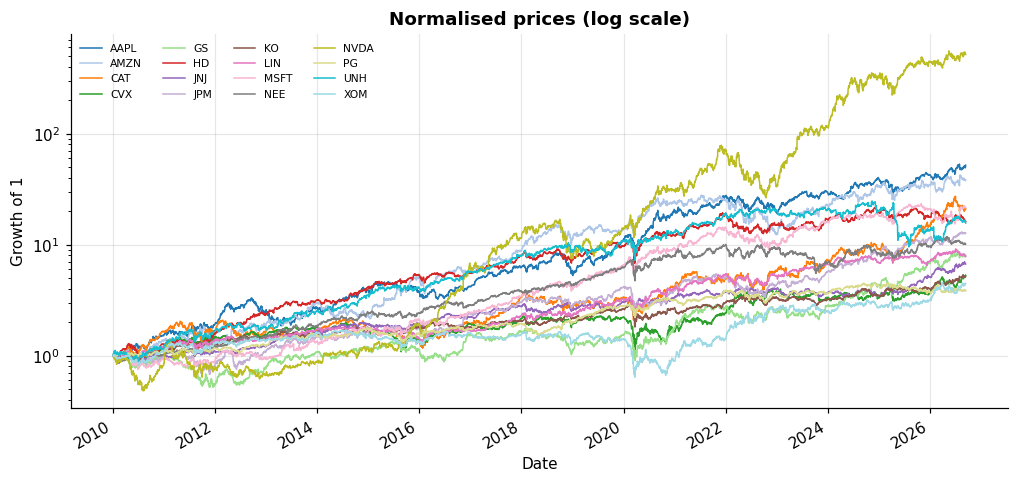

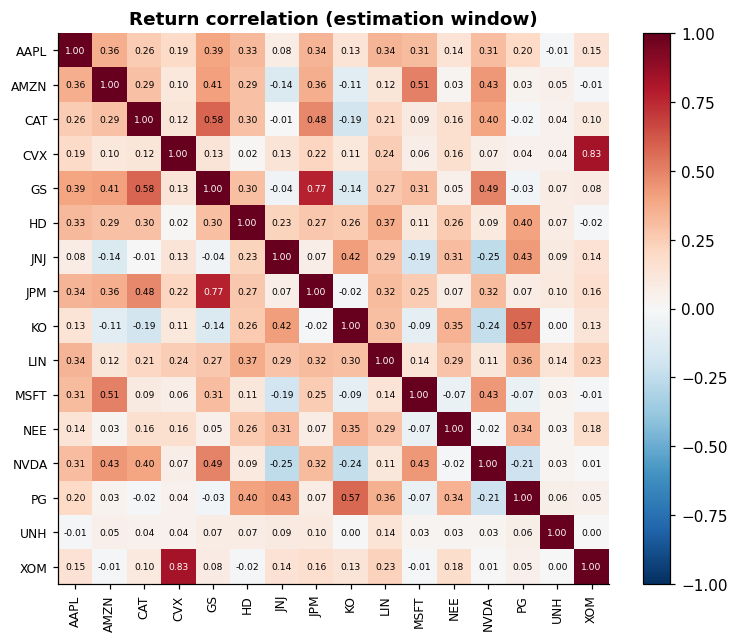

In [16]:
fig, ax = plt.subplots(figsize=(11, 5))
(prices / prices.iloc[0]).plot(ax=ax, lw=1, logy=True, cmap="tab20")
ax.set_title("Normalised prices (log scale)"); ax.set_ylabel("Growth of 1"); ax.legend(ncol=4, fontsize=7)
plots.save(fig, "01_prices"); plt.show()

window = returns.iloc[-MODEL.lookback_days:]
fig = plots.plot_correlation(window.corr()); plots.save(fig, "02_correlation"); plt.show()

## 4. Inputs: sample vs shrinkage estimates

The optimiser engine is compiled once for the universe and constraint set. Then we compare
the sample and Ledoit-Wolf covariance on the most recent estimation window, and show how the
shrinkage intensity depends on the window length relative to the number of assets.

In [17]:
cs = opt.ConstraintSet.from_config(len(assets), sectors.reindex(columns=assets).values)
engine = opt.ConvexEngine(cs)
rf_ann = float(rf.reindex(window.index).mean() * met.TRADING_DAYS)
w_mkt = data.market_weights_at(caps, window.index[-1]).reindex(assets)

e_sample = est.estimate(window, "sample", label="Sample")
e_lw = est.estimate(window, "ledoit_wolf", label="Ledoit-Wolf")
e_cc = est.estimate(window, "const_corr", label="Constant-correlation")
print(f"Estimation window: {window.index[0].date()} -> {window.index[-1].date()} ({len(window)} days), rf = {rf_ann:.2%}")
print(f"Ledoit-Wolf shrinkage intensity : {e_lw.cov.attrs['shrinkage']:.3f}")
print(f"Constant-corr shrinkage intensity: {e_cc.cov.attrs['shrinkage']:.3f}")
print(f"Condition number  sample: {est.condition_number(e_sample.cov):.1f}   LW: {est.condition_number(e_lw.cov):.1f}   CC: {est.condition_number(e_cc.cov):.1f}")

# Standard error of the mean vs the mean itself: this is the core problem.
se = np.sqrt(np.diag(e_sample.cov.values) / len(window))
inputs = pd.DataFrame({"mean (ann)": e_sample.mu, "std error": se, "t-stat": e_sample.mu / se,
                       "vol (ann)": np.sqrt(np.diag(e_sample.cov.values))}, index=assets)
display(inputs.style.format({"mean (ann)": "{:.1%}", "std error": "{:.1%}", "t-stat": "{:.2f}", "vol (ann)": "{:.1%}"}))
print(f"{(inputs['t-stat'].abs() < 2).sum()} of {len(assets)} expected returns are statistically indistinguishable from zero at 2 years of data.")

Estimation window: 2024-09-09 -> 2026-09-11 (504 days), rf = 4.04%
Ledoit-Wolf shrinkage intensity : 0.084
Constant-corr shrinkage intensity: 0.130
Condition number  sample: 42.6   LW: 23.9   CC: 26.1


,mean (ann),std error,t-stat,vol (ann)
AAPL,25.0%,1.3%,19.42,28.9%
AMZN,25.9%,1.5%,17.12,34.0%
CAT,52.9%,1.6%,33.80,35.1%
CVX,28.8%,1.1%,26.89,24.1%
GS,45.4%,1.4%,31.37,32.5%
HD,-2.3%,1.1%,-2.13,23.9%
JNJ,28.5%,0.9%,33.48,19.1%
JPM,31.0%,1.1%,27.90,25.0%
KO,15.2%,0.8%,19.10,17.9%
LIN,4.1%,0.8%,4.89,18.7%


0 of 16 expected returns are statistically indistinguishable from zero at 2 years of data.


,lw_shrinkage,cond_sample,cond_ledoit_wolf,n_over_t
window_days,,,,
63,0.357,57.416,7.313,0.254
126,0.173,45.314,14.896,0.127
252,0.122,34.516,16.156,0.063
504,0.084,42.600,23.931,0.032
756,0.052,39.970,27.915,0.021
1260,0.018,49.582,43.290,0.013


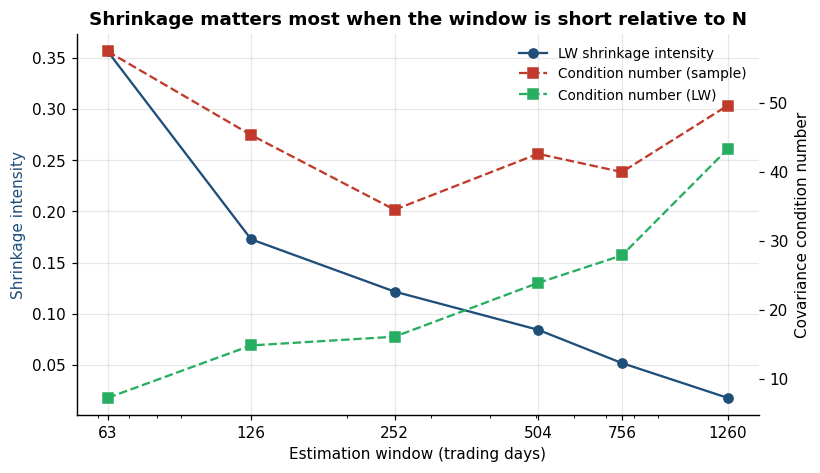

In [18]:
shrink_tbl = an.shrinkage_vs_window(returns)
display(shrink_tbl.round(3))
fig = plots.plot_shrinkage_vs_window(shrink_tbl); plots.save(fig, "03_shrinkage_vs_window"); plt.show()

**Read this before the horse race.** With 16 assets and 504 days, N/T ≈ 0.03 and the optimal
shrinkage intensity is small. Covariance shrinkage helps most when N/T is large (hundreds of
assets, short windows, or the instant after a regime change). In this configuration the
instability in mean-variance weights is dominated by the *means*, whose standard errors are
comparable to the means themselves. Keep this in mind when the sample-covariance and
Ledoit-Wolf MVO results look almost identical later: that is the correct outcome, not a bug.

## 5. Efficient frontiers: classical, shrinkage, resampled

All three curves are drawn in the coordinates of the *sample* estimates so they are comparable.
The Michaud frontier averages optimal weights by rank across simulated histories drawn from
N(μ̂, Σ̂); it lies inside the classical frontier by construction (it is not mean-variance
efficient; it is more stable).

frontiers computed in 18.0s (300 resampled draws)


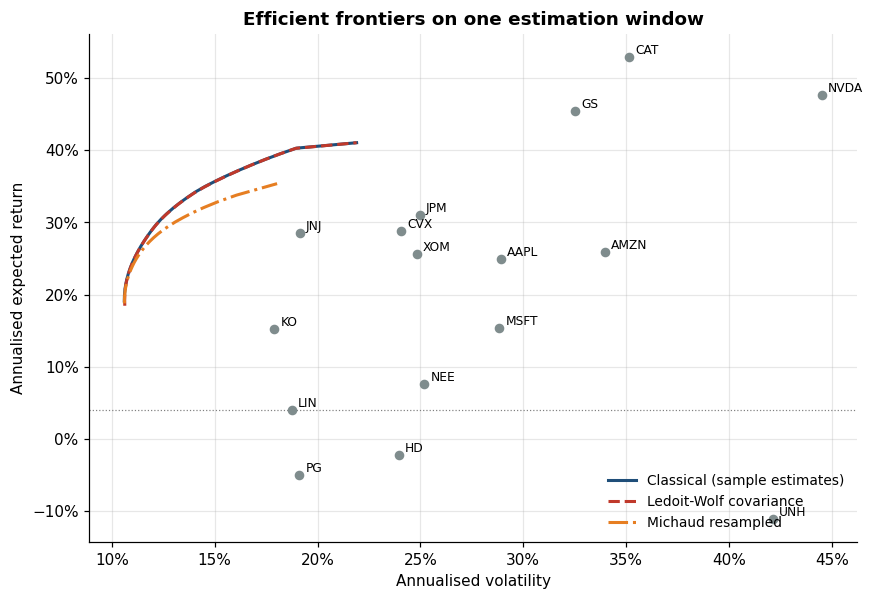

In [19]:
t0 = time.time()
fc = an.frontier_comparison(window, engine, n_points=30, n_resample=MODEL.n_resample_static)
print(f"frontiers computed in {time.time()-t0:.1f}s ({MODEL.n_resample_static} resampled draws)")
fig = plots.plot_frontiers(fc, rf_ann); plots.save(fig, "04_frontiers"); plt.show()

,ret,vol,sharpe,hhi,effective_n,max_weight
MVO (sample),32.7%,13.3%,2.16,0.160,6.2,20.0%
MVO (Ledoit-Wolf),32.8%,13.4%,2.15,0.153,6.6,20.0%
MVO (LW + shrunk means),29.7%,12.2%,2.11,0.135,7.4,20.0%
Michaud resampled,29.1%,12.5%,2.01,0.108,9.2,18.9%
Min variance (LW),18.5%,10.6%,1.36,0.113,8.8,19.5%
Risk parity (LW),18.7%,11.7%,1.26,0.068,14.6,10.6%
1/N,20.9%,13.1%,1.29,0.062,16.0,6.2%


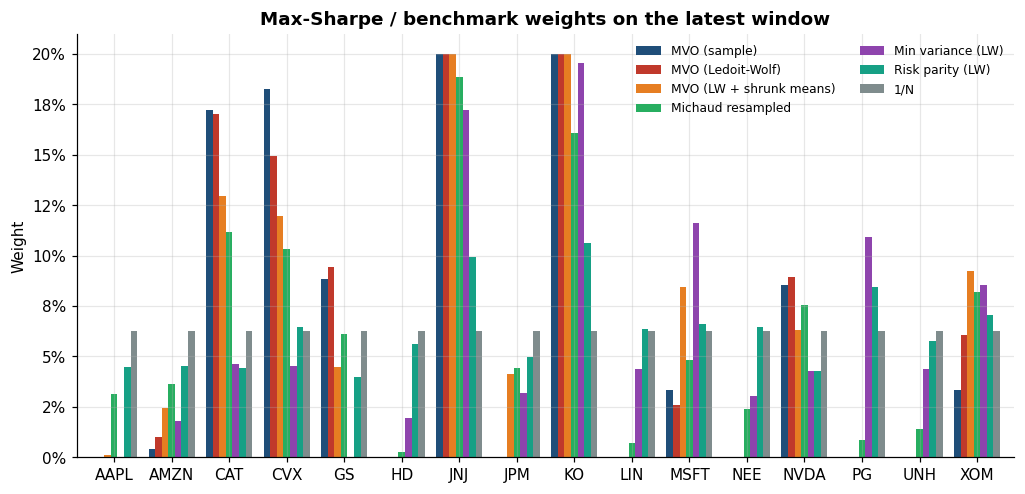

In [20]:
# Max-Sharpe portfolio under each input set, same constraints
mu_s, cov_s = e_sample.as_arrays()
w_tbl = pd.DataFrame({
    "MVO (sample)": engine.max_sharpe(mu_s, cov_s, rf_ann),
    "MVO (Ledoit-Wolf)": engine.max_sharpe(mu_s, e_lw.cov.values, rf_ann),
    "MVO (LW + shrunk means)": engine.max_sharpe(est.mean_shrunk(window).values, e_lw.cov.values, rf_ann),
    "Michaud resampled": opt.resampled_weights(engine, e_sample, len(window), n_sims=MODEL.n_resample_static, rf=rf_ann),
    "Min variance (LW)": engine.min_variance(e_lw.cov.values),
    "Risk parity (LW)": engine.risk_parity(e_lw.cov.values),
    "1/N": opt.equal_weight(len(assets)),
}, index=assets)
stats = pd.DataFrame({c: opt.portfolio_stats(w_tbl[c].values, mu_s, cov_s, rf_ann) for c in w_tbl}).T
display(stats.style.format({"ret": "{:.1%}", "vol": "{:.1%}", "sharpe": "{:.2f}", "hhi": "{:.3f}", "effective_n": "{:.1f}", "max_weight": "{:.1%}"}))
fig = plots.plot_weight_comparison(w_tbl, "Max-Sharpe / benchmark weights on the latest window"); plots.save(fig, "05_weights_static"); plt.show()

## 6. The instability experiment

Perturb each expected return by noise of one **standard error** (σᵢ/√T) — exactly the
estimation error a practitioner faces — and re-optimise. Repeat 200 times per method.
Methods that ignore μ (min variance, risk parity) are constant by construction; the
interesting comparison is among the methods that do use it.

instability experiment: 47.4s


,Mean L1 distance from base,Mean per-asset weight std,Max per-asset weight std,Avg effective N,Base Sharpe (in-sample)
Method,,,,,
MVO (Sample cov),0.118,0.96%,3.73%,6.3,2.16
MVO (Ledoit-Wolf cov),0.107,0.86%,2.98%,6.5,2.15
MVO (LW cov + shrunk means),0.078,0.62%,1.71%,7.4,2.11
Michaud Resampled,0.054,0.42%,0.92%,9.1,2.02
Black-Litterman (views = estimates),0.068,0.53%,1.05%,8.5,2.05
Minimum Variance (LW),0.000,0.00%,0.00%,8.8,1.36
Risk Parity (LW),0.000,0.00%,0.00%,14.6,1.26


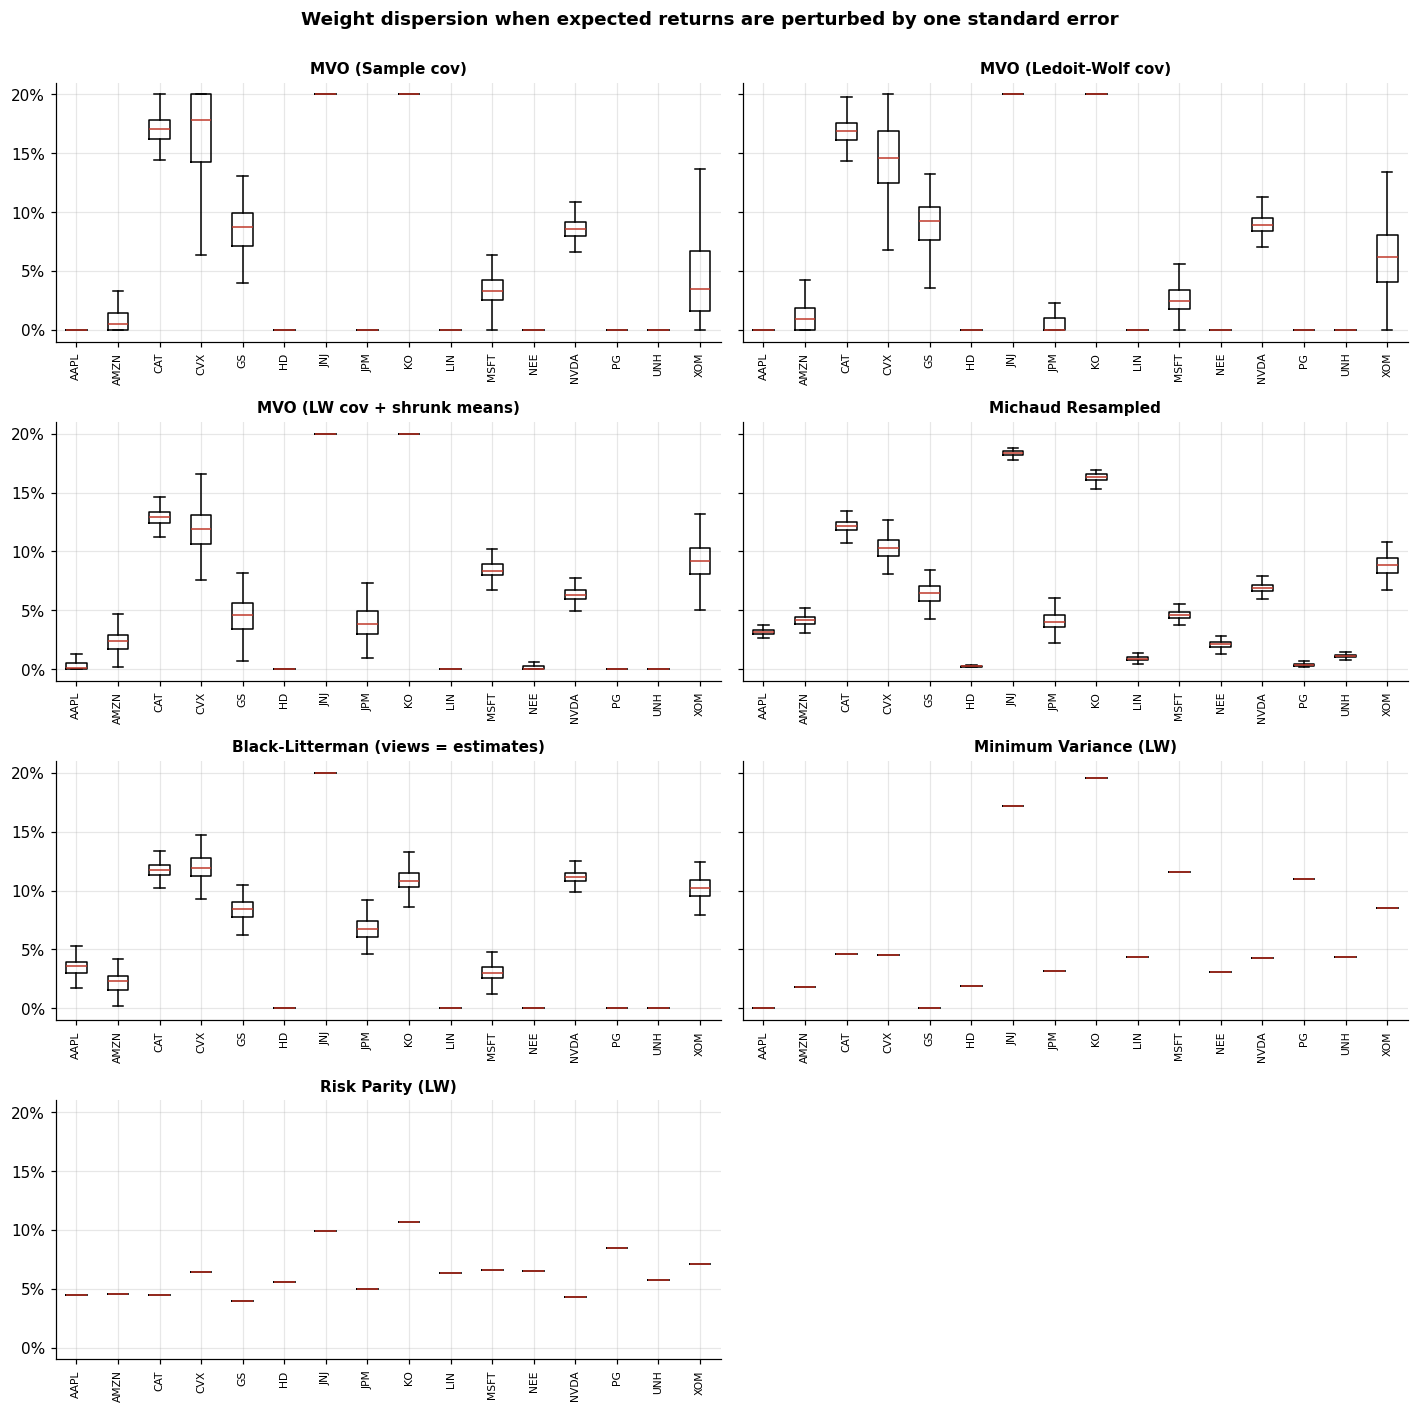

In [21]:
t0 = time.time()
instab_tbl, draws = an.instability_experiment(window, engine, w_mkt, rf_ann, n_trials=200, n_resample=MODEL.n_resample)
print(f"instability experiment: {time.time()-t0:.1f}s")
display(instab_tbl.style.format({"Mean L1 distance from base": "{:.3f}", "Mean per-asset weight std": "{:.2%}",
                                 "Max per-asset weight std": "{:.2%}", "Avg effective N": "{:.1f}", "Base Sharpe (in-sample)": "{:.2f}"})
        .background_gradient(subset=["Mean L1 distance from base"], cmap="Reds"))
instab_tbl.to_csv("outputs/tables/instability.csv")
fig = plots.plot_instability(draws, assets); plots.save(fig, "06_instability"); plt.show()

The classical optimiser moves roughly 10–12% of the portfolio in response to noise that is
statistically indistinguishable from nothing. Each fix reduces that: covariance shrinkage
slightly, mean shrinkage substantially, and Black-Litterman and Michaud the most among the
methods that still use return information. The cost is a lower *in-sample* Sharpe — which is
exactly the in-sample Sharpe you should not believe.

## 7. Black-Litterman walkthrough

1. **Reverse optimisation.** Π = δ Σ w_mkt gives the excess returns at which the market-cap
   portfolio is optimal. δ is estimated from the market's own Sharpe/variance and clipped to
   a sane range.
2. **Views.** Here: the systematic 12-1 momentum spread (top 4 beat bottom 4 by 5% p.a.),
   with He-Litterman uncertainty Ω = diag(P τΣ Pᵀ).
3. **Posterior.** Precision-weighted blend of Π and the views; then constrained mean-variance
   at δ.

The unconstrained textbook solution w* = (δΣ_BL)⁻¹ μ_BL is shown for reference — note it
contains short positions and does not sum to one, which is why practice uses the constrained
version.

market-implied risk aversion delta = 5.00   (bounds (1.0, 5.0), tau = 0.05)
view: JNJ+XOM+UNH+CAT beats HD+MSFT+PG+LIN by 5.0%


,prior,posterior,shift
AAPL,19.49%,18.48%,-1.01%
AMZN,23.25%,21.91%,-1.34%
CAT,14.99%,17.59%,2.60%
CVX,4.93%,6.27%,1.34%
GS,19.46%,19.81%,0.35%
HD,7.06%,5.34%,-1.72%
JNJ,-2.07%,-1.23%,0.84%
JPM,12.34%,12.68%,0.34%
KO,-1.38%,-2.10%,-0.71%
LIN,5.43%,4.55%,-0.88%


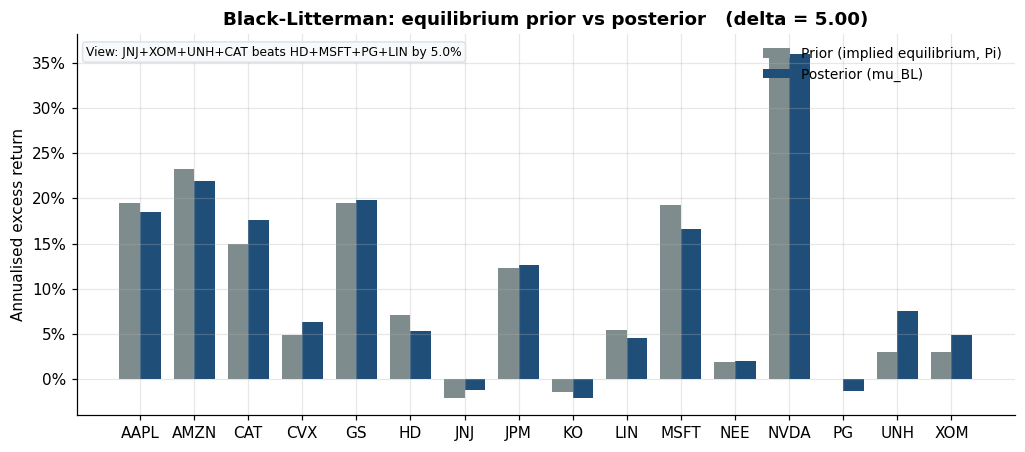

In [22]:
blw = an.bl_walkthrough(window, engine, w_mkt, rf)
post = blw["posterior"]
print(f"market-implied risk aversion delta = {blw['delta']:.2f}   (bounds {MODEL.bl_delta_bounds}, tau = {MODEL.bl_tau})")
for v in post.view_labels: print("view:", v)
display(post.summary().style.format("{:.2%}").background_gradient(subset=["shift"], cmap="RdBu_r", vmin=-0.05, vmax=0.05))
fig = plots.plot_bl_returns(post); plots.save(fig, "07_bl_prior_posterior"); plt.show()

Unconstrained BL weights  (sum = 0.95, min = -0.05, max = 0.23)


,Market cap,Prior (constrained MVO on Pi),Posterior (constrained MVO on mu_BL),Historical-mean MVO (for contrast)
AAPL,22.4%,8.8%,11.4%,0.0%
AMZN,12.8%,20.0%,17.8%,0.0%
CAT,1.7%,2.1%,7.1%,20.0%
CVX,1.9%,4.5%,3.8%,20.0%
GS,1.4%,8.2%,5.8%,20.0%
HD,1.4%,3.1%,0.0%,0.0%
JNJ,3.0%,1.4%,6.8%,20.0%
JPM,4.4%,4.7%,4.1%,0.0%
KO,1.8%,5.4%,2.8%,0.0%
LIN,1.0%,7.2%,0.0%,0.0%


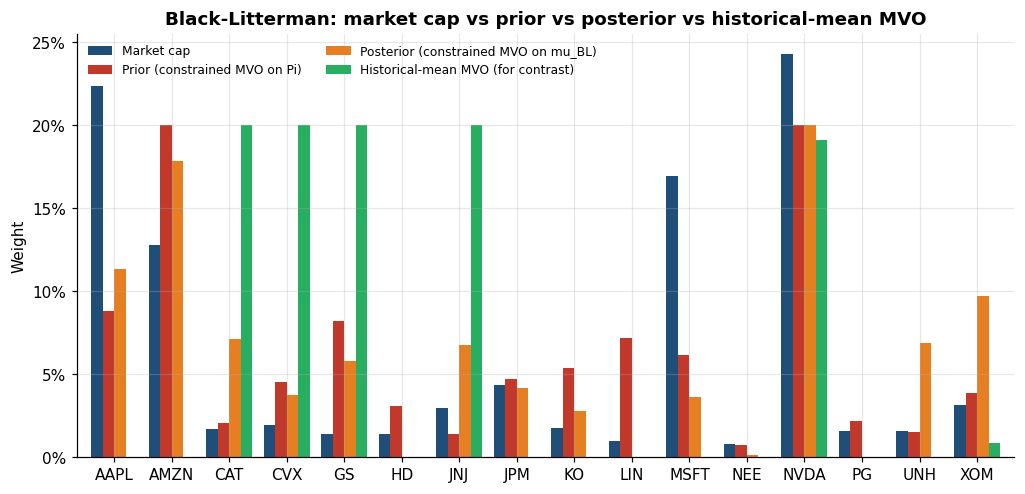

In [23]:
print("Unconstrained BL weights  (sum = %.2f, min = %.2f, max = %.2f)" % (blw["unconstrained"].sum(), blw["unconstrained"].min(), blw["unconstrained"].max()))
display(blw["weights"].style.format("{:.1%}").background_gradient(cmap="Blues", axis=None))
fig = plots.plot_weight_comparison(blw["weights"], "Black-Litterman: market cap vs prior vs posterior vs historical-mean MVO"); plots.save(fig, "08_bl_weights"); plt.show()

In [24]:
# Expressing a discretionary view: "NVDA outperforms MSFT by 8% p.a." at two confidence levels.
if all(t in assets for t in ["NVDA", "MSFT"]):
    view = bl.relative_view(assets, ["NVDA"], ["MSFT"], 0.08)
    for conf, label in [(np.array([4.0]), "low confidence (Omega x4)"), (np.array([0.25]), "high confidence (Omega /4)")]:
        r = bl.black_litterman(e_lw.cov, w_mkt, blw["delta"], [view], tau=MODEL.bl_tau, view_confidence=conf)
        w = engine.mean_variance(r.posterior_mu.values, r.posterior_cov.values, blw["delta"])
        print(f"{label:28s} posterior NVDA-MSFT spread = {r.posterior_mu['NVDA']-r.posterior_mu['MSFT']:+.2%}   "
              f"weights NVDA {w[assets.index('NVDA')]:.1%}  MSFT {w[assets.index('MSFT')]:.1%}")

low confidence (Omega x4)    posterior NVDA-MSFT spread = +15.23%   weights NVDA 17.8%  MSFT 8.3%
high confidence (Omega /4)   posterior NVDA-MSFT spread = +9.81%   weights NVDA 12.0%  MSFT 14.1%


## 8. Walk-forward backtest

Eight strategies, identical constraints, identical calendar. Monthly rebalancing on the last
trading day; estimates use the trailing 504 days up to and including that close; weights apply
from the next day and drift until the next rebalance. Turnover is measured against the
*drifted* holdings and capped at 50% (sum of absolute weight changes).

The Michaud strategy re-solves 100 resampled problems at every rebalance, which is most of the
runtime (about a minute in total thanks to the compiled solver).

In [25]:
for s in bt.DEFAULT_STRATEGIES:
    print(f"{s.name:38s} kind={s.kind:16s} cov={s.cov_method:12s} mean={s.mean_method}")

1/N Equal Weight                       kind=equal            cov=ledoit_wolf  mean=historical
MVO Max-Sharpe (Sample)                kind=max_sharpe       cov=sample       mean=historical
MVO Max-Sharpe (Ledoit-Wolf)           kind=max_sharpe       cov=ledoit_wolf  mean=historical
MVO Max-Sharpe (LW + Shrunk Means)     kind=max_sharpe       cov=ledoit_wolf  mean=shrunk
Michaud Resampled (Sample)             kind=resampled        cov=sample       mean=historical
Black-Litterman (Momentum views)       kind=black_litterman  cov=ledoit_wolf  mean=historical
Minimum Variance (Ledoit-Wolf)         kind=min_variance     cov=ledoit_wolf  mean=historical
Risk Parity (Ledoit-Wolf)              kind=risk_parity      cov=ledoit_wolf  mean=historical


In [26]:
t0 = time.time()
results = bt.run_backtest(returns, rf, caps, sectors, strategies=bt.DEFAULT_STRATEGIES,
                          model_cfg=MODEL, bt_cfg=BACKTEST, constraint_cfg=CONSTRAINTS, verbose=True)
print(f"backtest complete in {time.time()-t0:.0f}s")
first = next(iter(results.values()))
print(f"out-of-sample: {first.gross_returns.index[0].date()} -> {first.gross_returns.index[-1].date()}, "
      f"{len(first.target_weights)} rebalances")

COST = BACKTEST.cost_bps
net = bt.net_returns_frame(results, COST)
gross = pd.concat([r.gross_returns for r in results.values()], axis=1)
traded = pd.concat([r.traded.rename(k) for k, r in results.items()], axis=1)
weights = {k: r.target_weights for k, r in results.items()}

1/N Equal Weight:   0%|          | 0/177 [00:00<?, ?it/s]

MVO Max-Sharpe (Sample):   0%|          | 0/177 [00:00<?, ?it/s]

MVO Max-Sharpe (Sample):  15%|█▌        | 27/177 [00:00<00:00, 266.54it/s]

MVO Max-Sharpe (Sample):  33%|███▎      | 59/177 [00:00<00:00, 296.30it/s]

MVO Max-Sharpe (Sample):  50%|█████     | 89/177 [00:00<00:00, 297.39it/s]

...

Risk Parity (Ledoit-Wolf):  48%|████▊     | 85/177 [00:00<00:00, 283.41it/s]

Risk Parity (Ledoit-Wolf):  64%|██████▍   | 114/177 [00:00<00:00, 274.99it/s]

Risk Parity (Ledoit-Wolf):  80%|████████  | 142/177 [00:00<00:00, 275.22it/s]

Risk Parity (Ledoit-Wolf):  96%|█████████▌| 170/177 [00:00<00:00, 276.27it/s]

backtest complete in 49s
out-of-sample: 2012-02-01 -> 2026-09-11, 177 rebalances


## 9. Performance metrics

,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Daily VaR 95%,Daily CVaR 95%,Skew,Cost Drag (CAGR),Annual Turnover,Avg Effective N,Avg Max Weight,Weight Instability
1/N Equal Weight,20.58%,16.32%,1.12,1.61,-33.73%,0.61,1.47%,2.41%,-0.31,0.07%,59.07%,16.00,6.25%,0.00%
MVO Max-Sharpe (Sample),21.23%,17.49%,1.09,1.58,-30.14%,0.70,1.66%,2.53%,-0.13,0.38%,309.79%,5.92,20.00%,24.24%
MVO Max-Sharpe (Ledoit-Wolf),21.26%,17.53%,1.09,1.58,-30.15%,0.71,1.67%,2.54%,-0.13,0.37%,308.57%,5.96,19.99%,24.22%
MVO Max-Sharpe (LW + Shrunk Means),19.39%,16.06%,1.08,1.56,-30.46%,0.64,1.48%,2.29%,-0.15,0.35%,291.63%,6.50,19.95%,23.56%
Michaud Resampled (Sample),20.77%,16.59%,1.12,1.62,-30.28%,0.69,1.54%,2.41%,-0.13,0.22%,179.56%,8.69,18.21%,15.94%
Black-Litterman (Momentum views),20.15%,17.43%,1.04,1.50,-28.57%,0.71,1.65%,2.57%,-0.18,0.31%,258.10%,9.20,18.43%,21.02%
Minimum Variance (Ledoit-Wolf),12.74%,14.05%,0.80,1.14,-35.29%,0.36,1.20%,2.02%,-0.30,0.13%,114.90%,7.14,19.77%,7.66%
Risk Parity (Ledoit-Wolf),18.41%,15.21%,1.08,1.54,-33.85%,0.54,1.34%,2.22%,-0.30,0.07%,59.55%,14.63,10.55%,1.55%


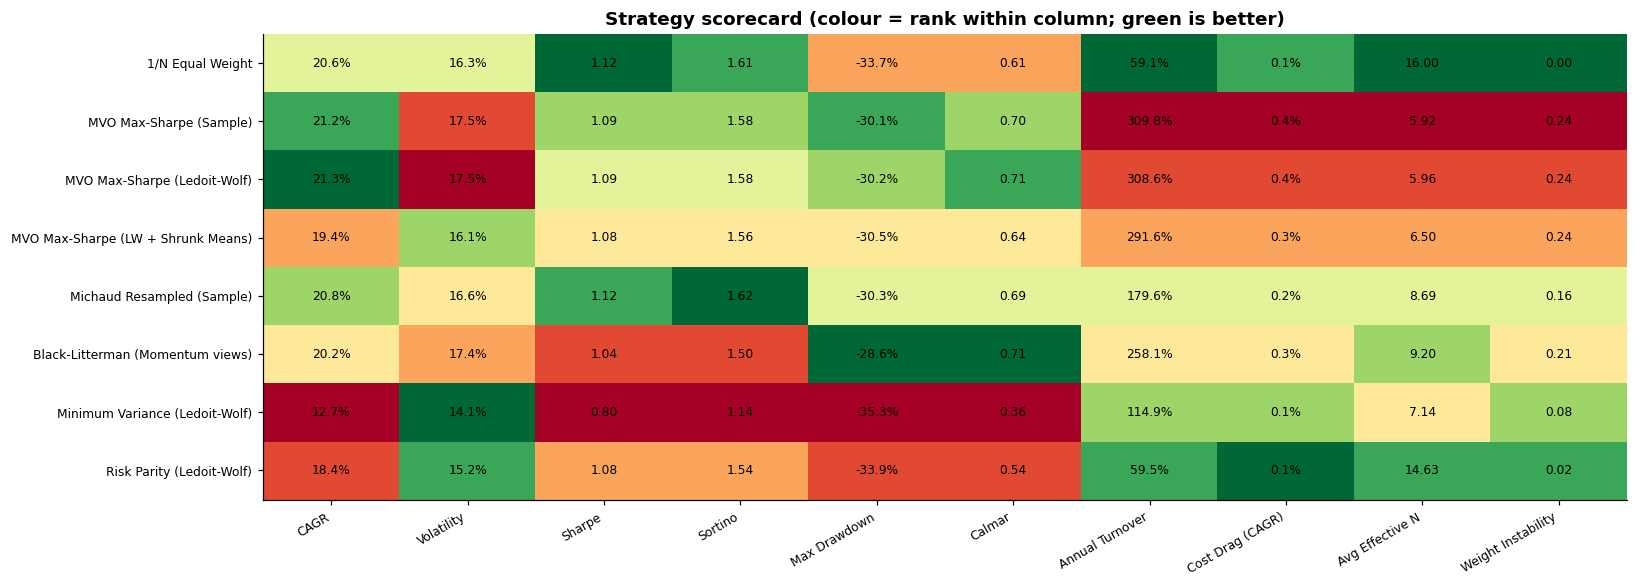

In [27]:
summary = met.summary_table(net, rf, gross, traded, weights)
summary.to_csv("outputs/tables/summary.csv")
display(met.format_summary(summary))
fig = plots.plot_summary_heatmap(summary, ["CAGR", "Volatility", "Sharpe", "Sortino", "Max Drawdown", "Calmar",
                                           "Annual Turnover", "Cost Drag (CAGR)", "Avg Effective N", "Weight Instability"])
plots.save(fig, "09_scorecard"); plt.show()

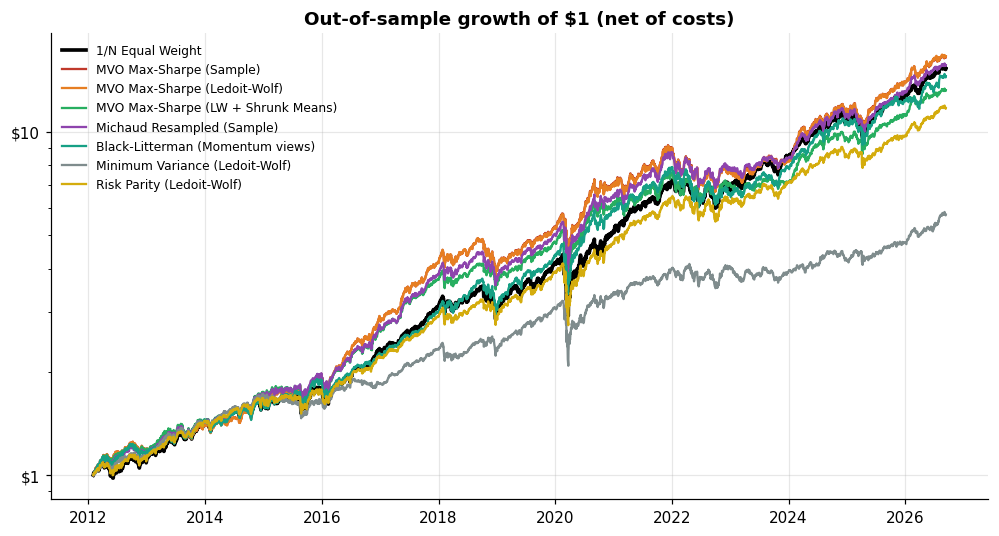

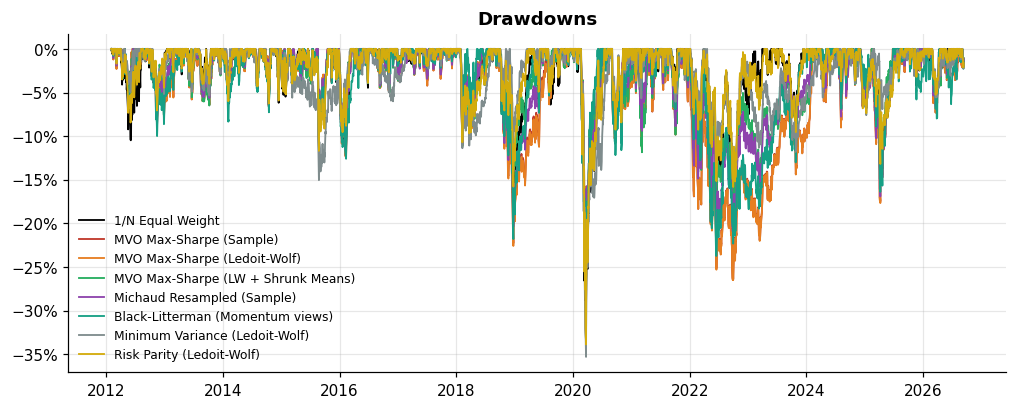

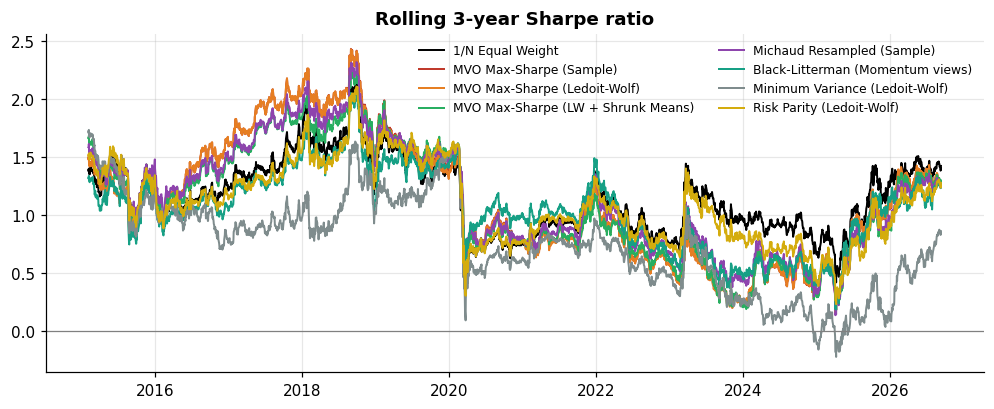

In [28]:
fig = plots.plot_cumulative(net); plots.save(fig, "10_cumulative"); plt.show()
fig = plots.plot_drawdowns(net); plots.save(fig, "11_drawdowns"); plt.show()
fig = plots.plot_rolling_sharpe(net, rf); plots.save(fig, "12_rolling_sharpe"); plt.show()

,1/N Equal Weight,MVO Max-Sharpe (Sample),MVO Max-Sharpe (Ledoit-Wolf),MVO Max-Sharpe (LW + Shrunk Means),Michaud Resampled (Sample),Black-Litterman (Momentum views),Minimum Variance (Ledoit-Wolf),Risk Parity (Ledoit-Wolf)
Date,,,,,,,,
2012,10.5%,17.5%,17.4%,17.2%,15.4%,15.1%,12.1%,11.5%
2013,29.8%,19.6%,19.6%,23.8%,25.6%,26.2%,28.1%,29.5%
2014,13.5%,18.2%,18.2%,18.5%,17.9%,11.2%,18.0%,14.4%
2015,8.6%,16.7%,16.9%,11.3%,14.1%,15.4%,-3.2%,5.9%
2016,30.2%,45.5%,45.5%,37.8%,36.9%,19.7%,12.5%,25.6%
2017,34.0%,47.3%,47.1%,41.0%,43.7%,33.2%,26.2%,31.5%
2018,-1.8%,-2.5%,-2.8%,-1.2%,-1.0%,5.9%,0.5%,0.4%
2019,36.7%,30.8%,30.7%,30.4%,32.8%,38.4%,31.7%,34.7%
2020,24.4%,34.3%,34.2%,30.4%,29.9%,37.2%,10.9%,22.4%


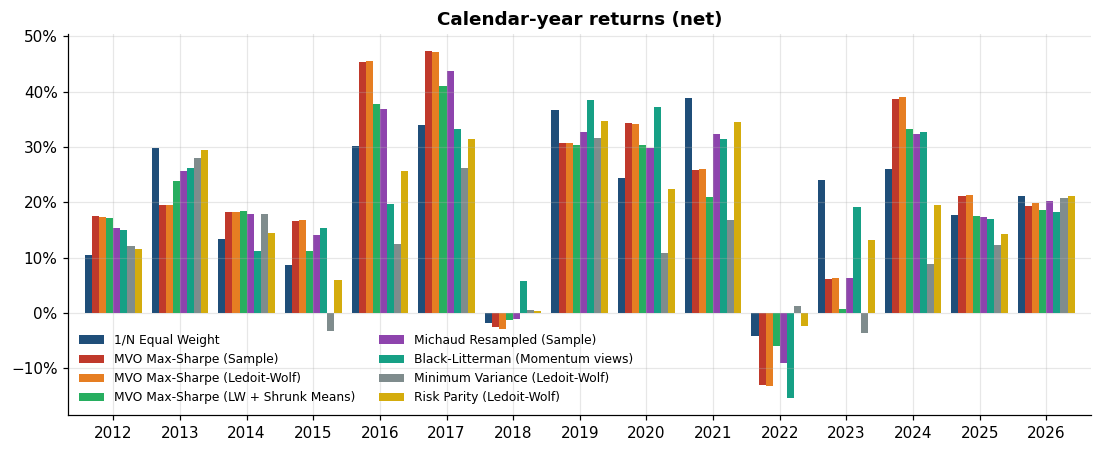

In [29]:
annual = met.annual_returns(net)
display(annual.style.format("{:.1%}").background_gradient(cmap="RdYlGn", axis=1))
fig = plots.plot_annual_returns(annual); plots.save(fig, "13_annual_returns"); plt.show()

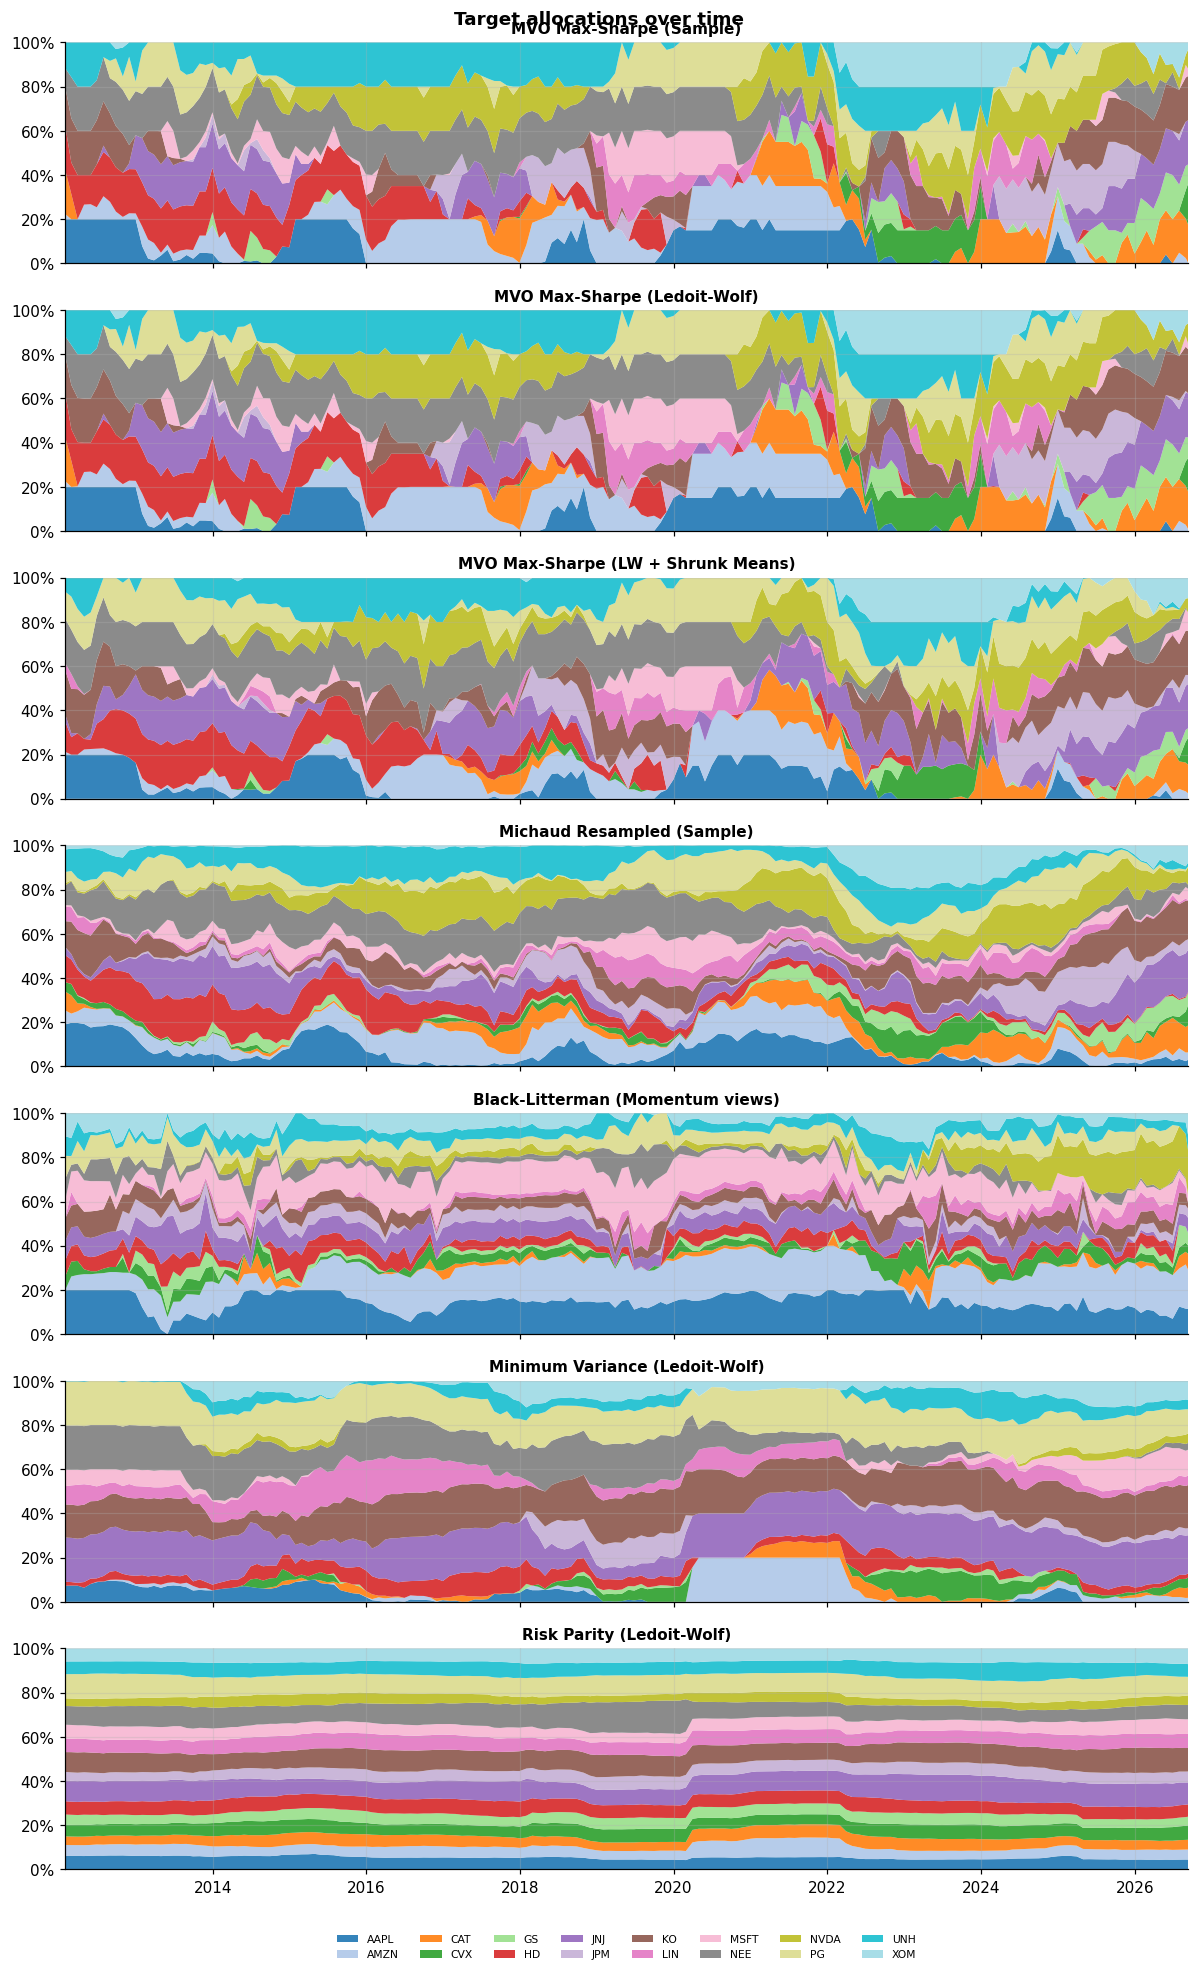

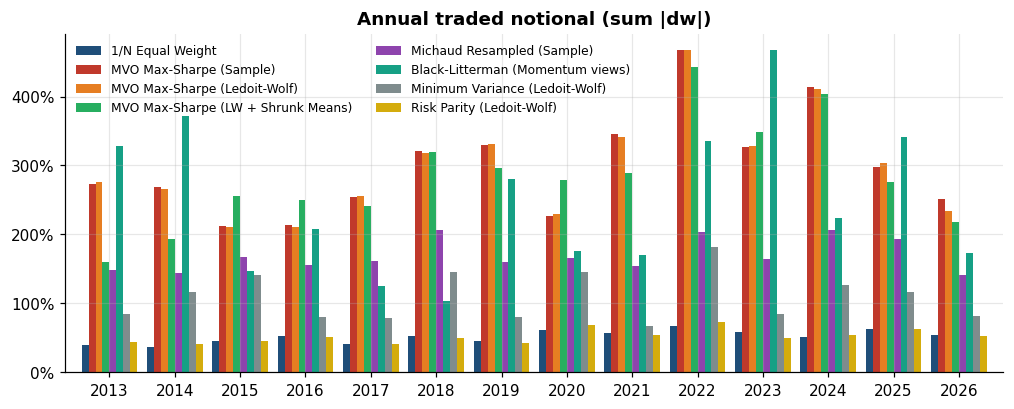

In [30]:
show = [k for k in results if k != "1/N Equal Weight"]
fig = plots.plot_allocation_grid(results, show); plots.save(fig, "14_allocations"); plt.show()
fig = plots.plot_turnover(traded); plots.save(fig, "15_turnover"); plt.show()

## 10. Transaction-cost sensitivity

Weights do not depend on the cost level, so net returns at any cost are
`gross − traded × cost` on the stored series. The break-even column is the cost per unit
traded at which each strategy's net Sharpe drops below 1/N's net Sharpe at the *same* cost
(0 = never ahead of 1/N; ∞ = ahead across the whole 0–200 bps grid).

,Sharpe @ 0 bps,Sharpe @ 5 bps,Sharpe @ 10 bps,Sharpe @ 25 bps,Sharpe @ 50 bps,Sharpe @ 100 bps,break-even bps vs 1/N
1/N Equal Weight,1.13,1.13,1.12,1.12,1.11,1.09,nan
MVO Max-Sharpe (Sample),1.11,1.10,1.09,1.06,1.02,0.93,0.00
MVO Max-Sharpe (Ledoit-Wolf),1.11,1.10,1.09,1.06,1.02,0.93,0.00
MVO Max-Sharpe (LW + Shrunk Means),1.10,1.09,1.08,1.05,1.01,0.91,0.00
Michaud Resampled (Sample),1.13,1.12,1.12,1.10,1.07,1.02,2.00
Black-Litterman (Momentum views),1.06,1.05,1.04,1.02,0.98,0.91,0.00
Minimum Variance (Ledoit-Wolf),0.81,0.81,0.80,0.79,0.77,0.73,0.00
Risk Parity (Ledoit-Wolf),1.08,1.08,1.08,1.07,1.06,1.04,0.00


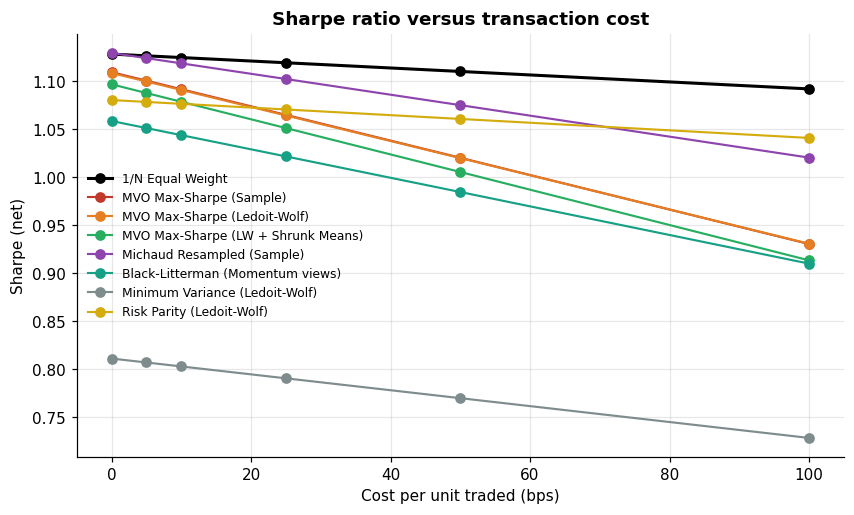

In [31]:
sens = an.cost_sensitivity(results, BACKTEST.cost_grid_bps, rf)
be = an.breakeven_cost_bps(results, "1/N Equal Weight", rf)
tbl = sens["sharpe"].copy(); tbl.columns = [f"Sharpe @ {c:g} bps" for c in tbl.columns]
tbl["break-even bps vs 1/N"] = be
display(tbl.style.format("{:.2f}").background_gradient(cmap="RdYlGn", axis=None, subset=tbl.columns[:-1]))
tbl.to_csv("outputs/tables/cost_sensitivity.csv")
fig = plots.plot_cost_sensitivity(sens["sharpe"]); plots.save(fig, "16_cost_sensitivity"); plt.show()

## 11. Is any of this statistically significant?

Jobson-Korkie test (Memmel correction) on monthly returns for H₀: Sharpe(strategy) = Sharpe(1/N).
With ~175 monthly observations and strategy correlations above 0.8, the power to detect
differences of 0.1–0.2 in annual Sharpe is low. That limitation is itself a finding.

In [32]:
sig = an.significance_vs_benchmark(net, rf, "1/N Equal Weight")
display(sig.style.format({"diff_ann": "{:+.3f}", "z": "{:+.2f}", "p_value": "{:.3f}", "corr": "{:.2f}", "n_periods": "{:.0f}"})
        .background_gradient(subset=["p_value"], cmap="Greens_r", vmin=0, vmax=0.5))
sig.to_csv("outputs/tables/significance_vs_1N.csv")

,diff_ann,z,p_value,corr,n_periods
MVO Max-Sharpe (Sample),-0.049,-0.31,0.758,0.84,176
MVO Max-Sharpe (Ledoit-Wolf),-0.051,-0.32,0.747,0.84,176
MVO Max-Sharpe (LW + Shrunk Means),-0.028,-0.18,0.860,0.84,176
Michaud Resampled (Sample),+0.010,+0.08,0.939,0.89,176
Black-Litterman (Momentum views),-0.106,-0.98,0.326,0.92,176
Minimum Variance (Ledoit-Wolf),-0.370,-2.34,0.019,0.83,176
Risk Parity (Ledoit-Wolf),-0.046,-0.95,0.340,0.98,176


## 12. Where the risk sits, and what each method holds today

Risk contribution (share of portfolio variance) under each strategy's latest target weights,
using the Ledoit-Wolf covariance from the latest window. Then the current target weights —
the practical output of the pipeline.

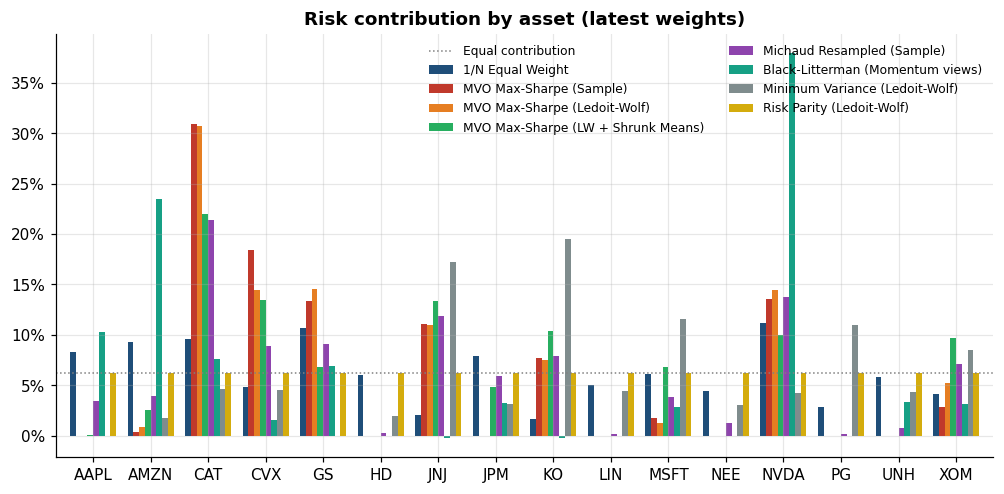

,1/N Equal Weight,MVO Max-Sharpe (Sample),MVO Max-Sharpe (Ledoit-Wolf),MVO Max-Sharpe (LW + Shrunk Means),Michaud Resampled (Sample),Black-Litterman (Momentum views),Minimum Variance (Ledoit-Wolf),Risk Parity (Ledoit-Wolf)
target weights as of 2026-09-11,,,,,,,,
AAPL,6.2%,0.0%,0.0%,0.1%,3.0%,11.4%,0.0%,4.5%
AMZN,6.2%,0.4%,1.0%,2.4%,3.4%,17.8%,1.8%,4.5%
CAT,6.2%,17.2%,17.0%,13.0%,12.2%,7.1%,4.6%,4.4%
CVX,6.2%,18.3%,14.9%,12.0%,9.1%,3.8%,4.5%,6.5%
GS,6.2%,8.8%,9.4%,4.5%,5.5%,5.8%,0.0%,4.0%
HD,6.2%,0.0%,0.0%,0.0%,0.4%,0.0%,1.9%,5.6%
JNJ,6.2%,20.0%,20.0%,20.0%,19.2%,6.8%,17.2%,9.9%
JPM,6.2%,0.0%,0.0%,4.1%,4.8%,4.1%,3.2%,4.9%
KO,6.2%,20.0%,20.0%,20.0%,17.5%,2.8%,19.5%,10.6%


,1/N Equal Weight,MVO Max-Sharpe (Sample),MVO Max-Sharpe (Ledoit-Wolf),MVO Max-Sharpe (LW + Shrunk Means),Michaud Resampled (Sample),Black-Litterman (Momentum views),Minimum Variance (Ledoit-Wolf),Risk Parity (Ledoit-Wolf)
Consumer Discretionary,12.5%,0.4%,1.0%,2.4%,3.8%,17.8%,3.7%,10.1%
Consumer Staples,12.5%,20.0%,20.0%,20.0%,17.9%,2.8%,30.5%,19.1%
Energy,12.5%,21.6%,21.0%,21.2%,17.0%,13.5%,13.1%,13.5%
Financials,12.5%,8.8%,9.4%,8.6%,10.3%,10.0%,3.2%,8.9%
Health Care,12.5%,20.0%,20.0%,20.0%,20.8%,13.7%,21.6%,15.7%
Industrials,6.2%,17.2%,17.0%,13.0%,12.2%,7.1%,4.6%,4.4%
Materials,6.2%,0.0%,0.0%,0.0%,0.2%,0.0%,4.4%,6.4%
Technology,18.8%,11.9%,11.5%,14.8%,15.9%,35.0%,15.9%,15.4%
Utilities,6.2%,0.0%,0.0%,0.0%,1.9%,0.1%,3.1%,6.5%


In [33]:
rc = an.risk_contribution_table(results, e_lw.cov)
fig = plots.plot_risk_contributions(rc); plots.save(fig, "17_risk_contributions"); plt.show()

latest = pd.DataFrame({k: r.target_weights.iloc[-1] for k, r in results.items()})
latest.index.name = f"target weights as of {first.target_weights.index[-1].date()}"
display(latest.style.format("{:.1%}").background_gradient(cmap="Blues", axis=None))
latest.to_csv("outputs/tables/latest_target_weights.csv")
sector_exp = sectors.reindex(columns=assets) @ latest
display(sector_exp.style.format("{:.1%}"))

In [34]:
# Persist everything a reviewer would want to re-analyse
net.to_csv("outputs/tables/net_returns_daily.csv")
gross.to_csv("outputs/tables/gross_returns_daily.csv")
traded.to_csv("outputs/tables/traded_notional_daily.csv")
for k, r in results.items():
    safe = "".join(ch if ch.isalnum() else "_" for ch in k)
    r.target_weights.to_csv(f"outputs/tables/weights_{safe}.csv")
    if not r.diagnostics.empty:
        r.diagnostics.to_csv(f"outputs/tables/diagnostics_{safe}.csv")
print("saved:", sorted(os.listdir("outputs/tables"))[:8], "...")
print("figures:", len(os.listdir("outputs/figures")))

saved: ['cost_sensitivity.csv', 'diagnostics_Black_Litterman__Momentum_views_.csv', 'diagnostics_MVO_Max_Sharpe__LW___Shrunk_Means_.csv', 'diagnostics_MVO_Max_Sharpe__Ledoit_Wolf_.csv', 'diagnostics_MVO_Max_Sharpe__Sample_.csv', 'diagnostics_Michaud_Resampled__Sample_.csv', 'diagnostics_Minimum_Variance__Ledoit_Wolf_.csv', 'diagnostics_Risk_Parity__Ledoit_Wolf_.csv'] ...
figures: 17


## 13. Interpretation

Write your own conclusions from the tables above; the template below is what the results
have typically shown on this universe and will need editing after each run.

**What the experiments show**

1. **Estimation error dominates.** On a 2-year window most expected returns have |t| < 2.
   The classical optimiser reacts to that noise by moving ~10% of the book (Section 6).
2. **Covariance shrinkage is not the main fix here.** With N/T ≈ 0.03 the optimal Ledoit-Wolf
   intensity is under 10%, so sample-covariance and LW mean-variance behave nearly identically.
   Shrinkage earns its keep at high N/T. Mean shrinkage, Black-Litterman and resampling reduce
   instability far more because they act on μ.
3. **1/N is a serious benchmark.** Out of sample and net of costs, the optimised strategies
   land within a narrow Sharpe band around equal weight, with turnover three to five times
   higher. None of the differences is significant at conventional levels (Section 11). This is
   consistent with DeMiguel, Garlappi & Uppal (2009).
4. **Costs decide the ranking.** At realistic institutional costs (5–10 bps) the ordering
   barely moves; at 25–50 bps the high-turnover optimisers fall below 1/N (Section 10).
   Turnover, not in-sample Sharpe, is the first number to look at.
5. **Minimum variance is a different bet.** It delivered the lowest volatility and a lower
   Sharpe over a period dominated by a mega-cap growth rally; its relative performance is
   regime-dependent and its sector concentration is the highest of any method.
6. **Risk parity's edge is structural, not return-driven.** Near-1/N turnover, no dependence
   on μ, and the most even risk contributions; its Sharpe tracks 1/N closely.

**Honest caveats**

- One universe, one sample period, survivorship in the universe choice (these 16 are today's
  large caps). Robustness across universes and start dates is the obvious next step.
- The momentum view in Black-Litterman is a demonstration of *systematic* view construction,
  not a claim that momentum plus BL beats the market.
- Costs are modelled as proportional; market impact for a large book would penalise the
  high-turnover methods more.
- The Sharpe test assumes approximately iid monthly returns; a HAC-robust test (Ledoit & Wolf
  2008) is the correct upgrade.

## 14. Potential upgrades

| Upgrade | Why it matters |
|---|---|
| Factor-model covariance (PCA / Fama-French residual structure) | Scales to hundreds of assets where sample and even LW estimates degrade |
| Robust optimisation (Goldfarb-Iyengar uncertainty sets, CVaR objective) | Optimises the worst case over an estimation-error set rather than the point estimate |
| Hierarchical Risk Parity (López de Prado 2016) | Avoids covariance inversion entirely; compare stability with ERC |
| Idzorek confidence mapping for Black-Litterman | Express view confidence as a percentage instead of an Ω multiplier |
| Regime-conditional estimation (HMM / Markov switching) | Let μ and Σ depend on the detected regime rather than a fixed trailing window |
| Multi-period optimisation with transaction-cost-aware objectives (Gârleanu-Pedersen) | Trade toward the target gradually instead of a hard turnover cap |
| Ledoit-Wolf (2008) HAC Sharpe test, bootstrap confidence bands, White's reality check | Proper multiple-testing control across the strategy set |
| Broader universes (S&P 500 constituents with point-in-time membership) and rolling start dates | The single most important robustness check for any allocation study |
| Live paper-trading loop with a broker API and daily risk report | Turns the research code into an operating system |